  VWAP MEAN-REVERSION STUDY v3  — initialising

[A] Loading and processing tick data...

[B] Fetching external regime data (yfinance + cache)...
  VIX fetch failed: `a` must be 1-dimensional.
  SPY ATR: loaded from cache (spy_atr_2026-05-12)

[C] Computing regime classification...

[D] Detecting events and classifying with execution model...

[E] Running bootstrap / MC baseline (5,000 iterations)...

[F] Computing performance metrics...

[G] Sensitivity analysis...

[H] Generating report and charts...

════════════════════════════════════════════════════════════════════════════
  VWAP MEAN-REVERSION STUDY v3  |  2026-05-12  |  NY RTH
════════════════════════════════════════════════════════════════════════════
  Bars (seconds)  : 22,500
  Total volume    : 1,282,316
  Open / Close    : 7414.25 / 7427.75
  Session VWAP    : 7395.85
  Final σ         : 18.5439
  SD2 events      : 80  (upper=21, lower=59)

────────────────────────────────────────────────────────────────────────────
  SESSI

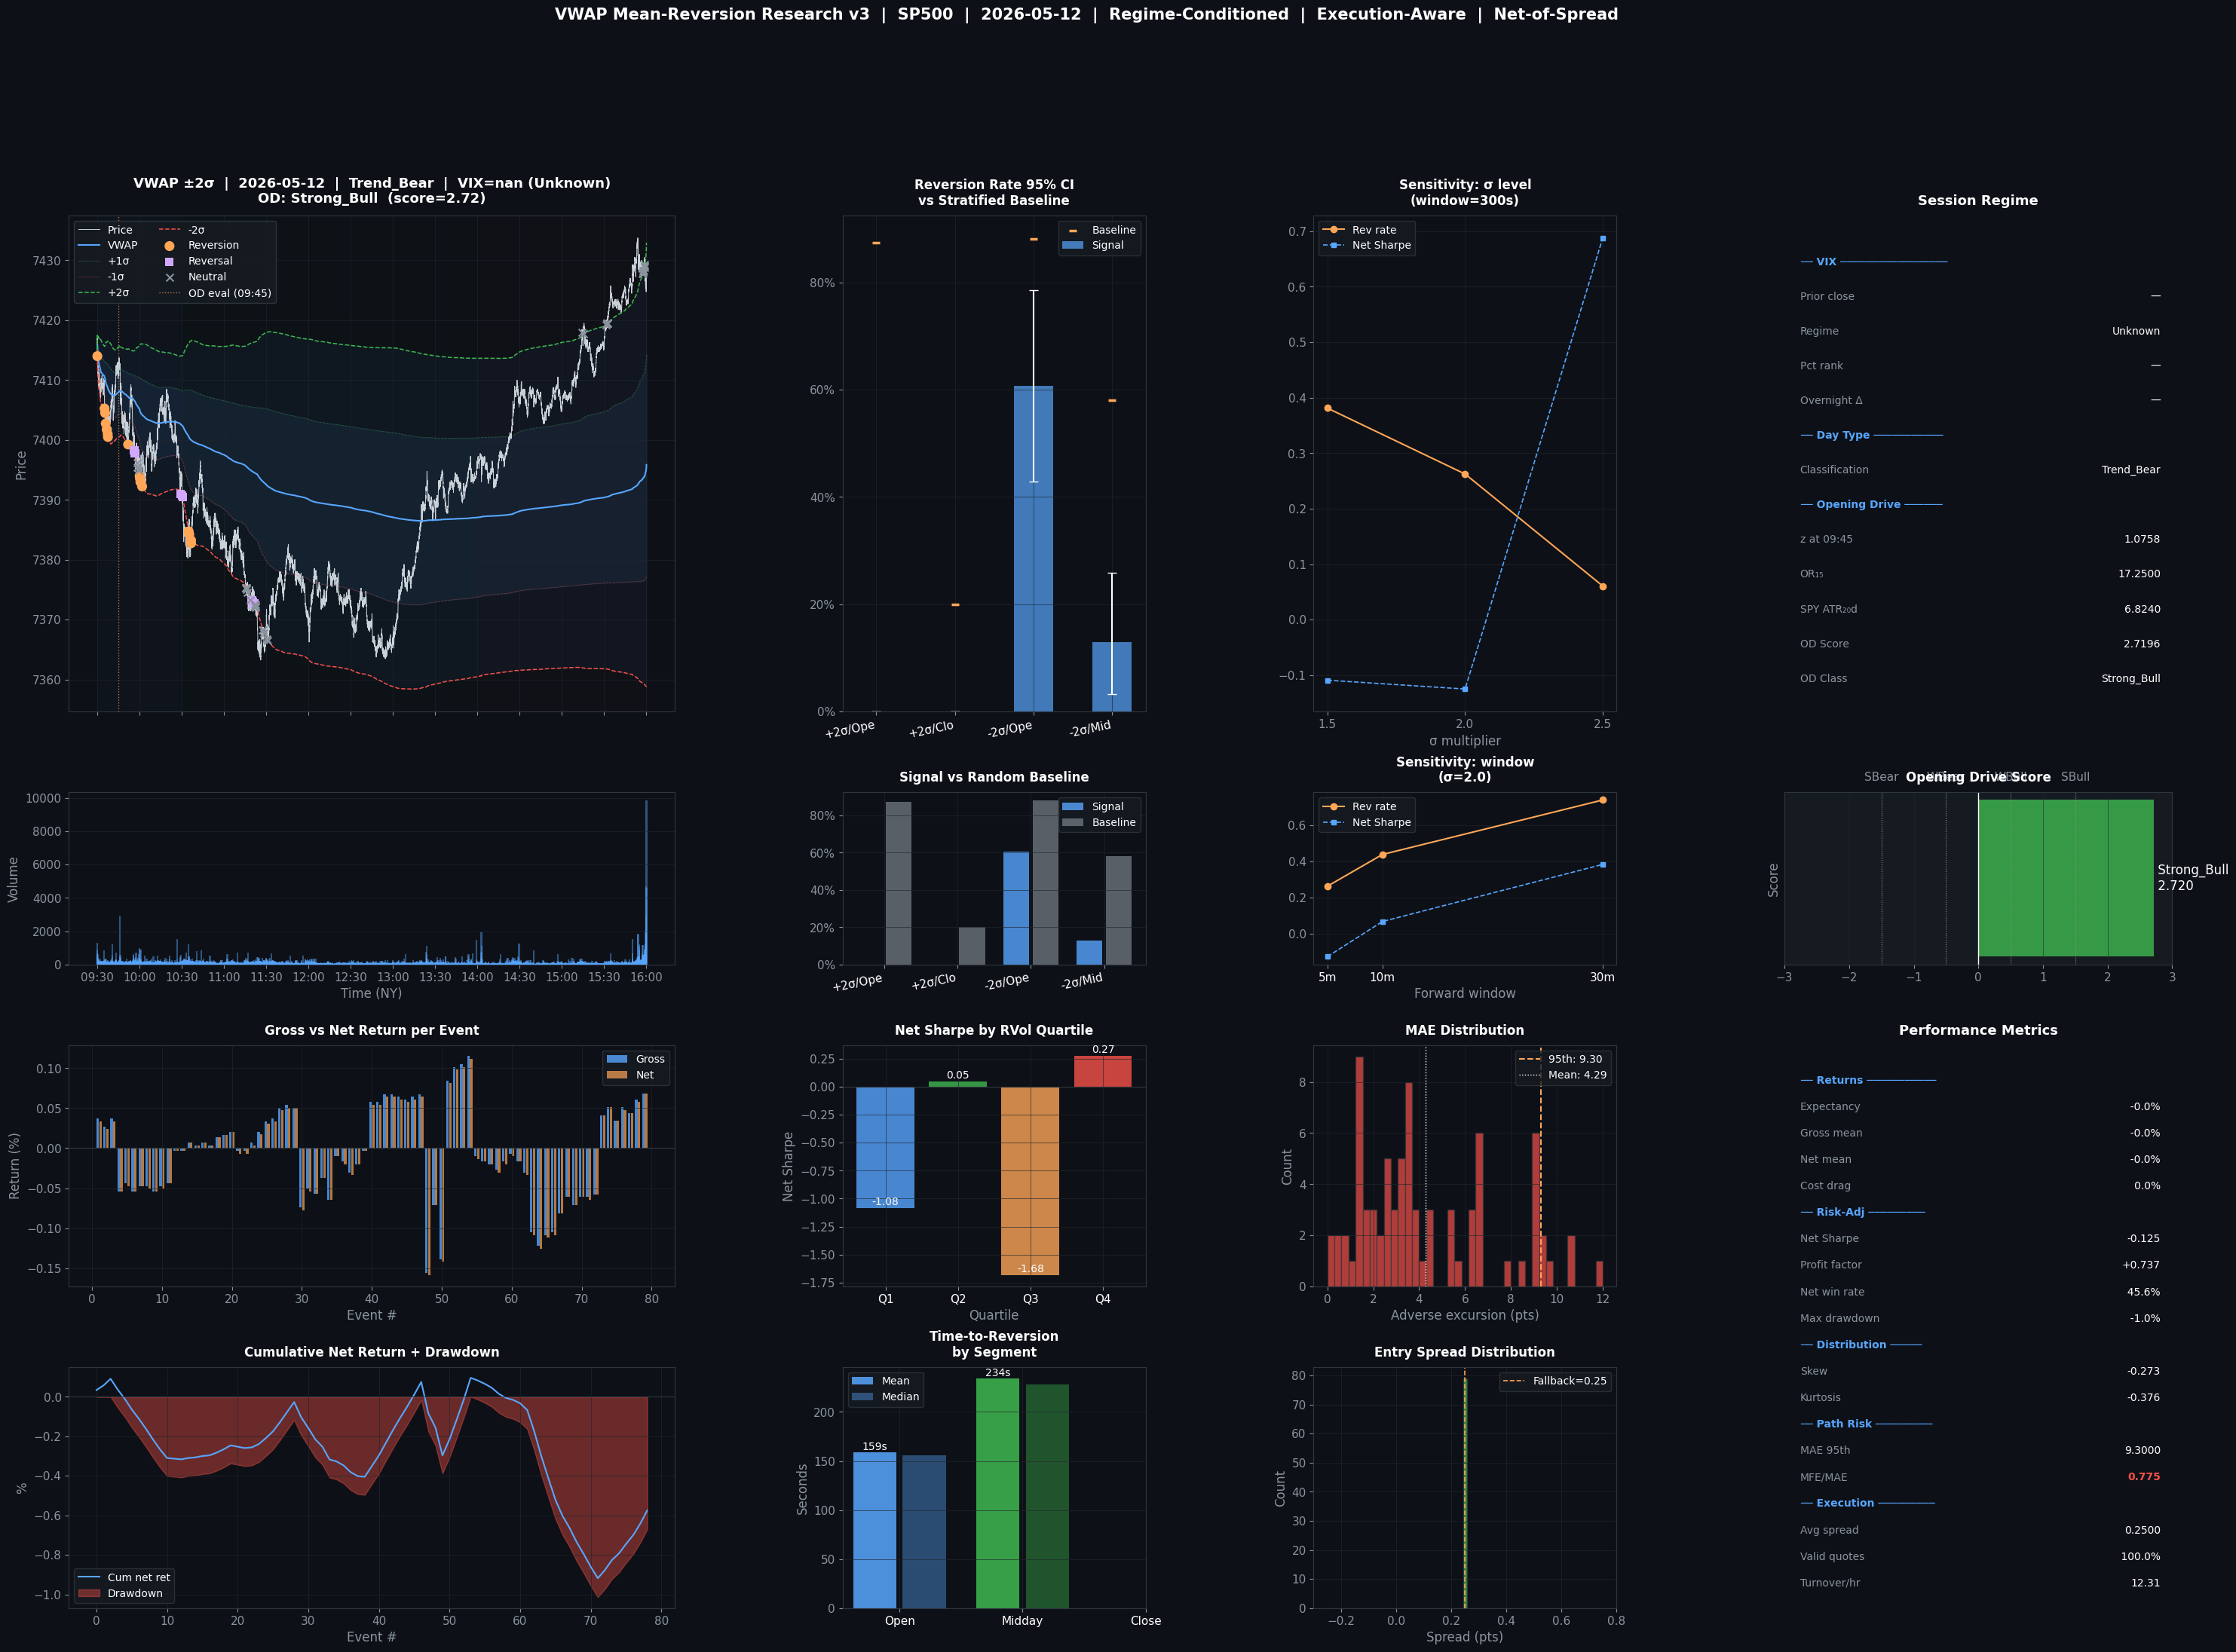

Chart saved → vwap_analysis.png


In [ ]:
"""
VWAP deviation mean-reversion study (ES futures, tick → second bars, NY RTH).

Refactor highlights:
- pathlib + argparse, single `main()` entry
- `RunConfig` dataclass for parameters
- Type hints on public surfaces
- Bonferroni: compare `p_bonferroni` to family-wise α (adjusted p = min(p×k, 1))
- Plot/report helpers de-duplicated
"""
from __future__ import annotations

import argparse
import json
import warnings
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any, Literal
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.figure import Figure
from matplotlib.ticker import FuncFormatter
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import yfinance as yf

    YF_AVAILABLE = True
except ImportError:
    YF_AVAILABLE = False
    yf = None  # type: ignore[assignment]


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────

VILNIUS_TZ = ZoneInfo("Europe/Vilnius")
NY_TZ = ZoneInfo("America/New_York")

SEGMENTS: dict[str, tuple[str, str]] = {
    "Open": ("09:30", "10:30"),
    "Midday": ("10:30", "14:00"),
    "Close": ("14:00", "16:00"),
}

SIGMA_SWEEP: tuple[float, ...] = (1.5, 2.0, 2.5)
WINDOW_SWEEP: tuple[int, ...] = (300, 600, 1800)
BONFERRONI_K_DEFAULT = 6
OD_EVAL_TIME = "09:45"
VIX_LOOKBACK_DAYS = 252
ATR_PERIOD = 20

RTH_SECONDS = int(6.5 * 60 * 60)
RVOL_ROLL_SECONDS = 300
RVOL_MIN_PERIODS = 30

TREND_SLOPE_SD_FRAC = 0.5
TREND_OUTSIDE_ONE_SIGMA_FRAC = 0.40
MAX_SPREAD_POINTS = 5.0
SESSION_HOURS = 6.5


@dataclass(frozen=True, slots=True)
class RunConfig:
    csv_path: Path
    ny_session_start: str = "09:30"
    ny_session_end: str = "16:00"
    forward_window_s: int = 300
    neutral_threshold: float = 0.5
    bootstrap_n: int = 5_000
    random_seed: int = 42
    default_spread: float = 0.25
    latency_bars: int = 1
    sigma_primary: float = 2.0
    cache_dir: Path | None = None
    output_chart: Path = Path("vwap_analysis.png")
    show_plot: bool = True
    bonferroni_k: int = BONFERRONI_K_DEFAULT
    family_wise_alpha: float = 0.05

    def resolved_cache_dir(self) -> Path:
        if self.cache_dir is not None:
            return self.cache_dir
        # Notebooks / `exec` cells do not define __file__; scripts do.
        try:
            base = Path(__file__).resolve().parent
        except NameError:
            base = Path.cwd()
        return base / ".vwap_cache"



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Data pipeline
# ═══════════════════════════════════════════════════════════════════════════


def load_and_filter(
    csv_path: Path,
    ny_session_start: str,
    ny_session_end: str,
) -> tuple[pd.DataFrame, Any, pd.Timestamp, pd.Timestamp]:
    df = pd.read_csv(
        csv_path,
        header=None,
        names=["Time", "Price", "Bid", "Ask", "Volume"],
    )
    df["Time"] = pd.to_datetime(df["Time"], format="%Y%m%d %H%M%S")
    df["Time"] = df["Time"].dt.tz_localize(VILNIUS_TZ).dt.tz_convert(NY_TZ)
    session_date = df["Time"].dt.date.mode().iloc[0]
    session_start = pd.Timestamp(f"{session_date} {ny_session_start}", tz=NY_TZ)
    session_end = pd.Timestamp(f"{session_date} {ny_session_end}", tz=NY_TZ)
    df = df[(df["Time"] >= session_start) & (df["Time"] <= session_end)].copy()
    if df.empty:
        raise ValueError("No data in NY RTH window. Check CSV timezone.")
    return df, session_date, session_start, session_end


def aggregate_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["Time_sec"] = d["Time"].dt.floor("s")
    ohlcv = (
        d.groupby("Time_sec", sort=True)
        .agg(
            Open=("Price", "first"),
            High=("Price", "max"),
            Low=("Price", "min"),
            Close=("Price", "last"),
            Volume=("Volume", "sum"),
            Bid=("Bid", "last"),
            Ask=("Ask", "last"),
        )
        .reset_index()
    )
    ohlcv["TypicalPrice"] = (ohlcv["High"] + ohlcv["Low"] + ohlcv["Close"]) / 3
    return ohlcv


def compute_vwap_bands(ohlcv: pd.DataFrame, sigma_mult: float = 2.0) -> pd.DataFrame:
    o = ohlcv.copy()
    o["CumTPV"] = (o["TypicalPrice"] * o["Volume"]).cumsum()
    o["CumVol"] = o["Volume"].cumsum()
    o["VWAP"] = o["CumTPV"] / o["CumVol"]
    o["CumTPV2"] = (o["TypicalPrice"] ** 2 * o["Volume"]).cumsum()
    o["VWAPVar"] = (o["CumTPV2"] / o["CumVol"]) - (o["VWAP"] ** 2)
    o["VWAPVar"] = o["VWAPVar"].clip(lower=0)
    o["VWAP_SD"] = np.sqrt(o["VWAPVar"])
    o["VWAP_Upper1"] = o["VWAP"] + o["VWAP_SD"]
    o["VWAP_Lower1"] = o["VWAP"] - o["VWAP_SD"]
    o["VWAP_UpperN"] = o["VWAP"] + sigma_mult * o["VWAP_SD"]
    o["VWAP_LowerN"] = o["VWAP"] - sigma_mult * o["VWAP_SD"]
    return o


def assign_segments(
    ohlcv: pd.DataFrame,
    session_date: Any,
) -> tuple[pd.DataFrame, dict[str, tuple[pd.Timestamp, pd.Timestamp]]]:
    bounds = {
        name: (
            pd.Timestamp(f"{session_date} {s}", tz=NY_TZ),
            pd.Timestamp(f"{session_date} {e}", tz=NY_TZ),
        )
        for name, (s, e) in SEGMENTS.items()
    }

    def _seg(ts: pd.Timestamp) -> str:
        for name, (sx, ex) in bounds.items():
            if sx <= ts < ex:
                return name
        return "Close"

    o = ohlcv.copy()
    o["Segment"] = o["Time_sec"].map(_seg)
    return o, bounds



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# External data
# ═══════════════════════════════════════════════════════════════════════════


def _cache_path(cache_dir: Path, key: str) -> Path:
    return cache_dir / f"{key}.json"


def _load_cache(cache_dir: Path, key: str) -> Any | None:
    p = _cache_path(cache_dir, key)
    if p.exists():
        with p.open(encoding="utf-8") as f:
            return json.load(f)
    return None


def _save_cache(cache_dir: Path, key: str, data: Any) -> None:
    cache_dir.mkdir(parents=True, exist_ok=True)
    with _cache_path(cache_dir, key).open("w", encoding="utf-8") as f:
        json.dump(data, f)


def fetch_vix_regime(session_date: Any, cache_dir: Path) -> dict[str, Any]:
    key = f"vix_{session_date}"
    cached = _load_cache(cache_dir, key)
    if cached:
        print(f"  VIX: loaded from cache ({key})")
        return cached

    if not YF_AVAILABLE or yf is None:
        return {
            "vix_prior_close": np.nan,
            "vix_overnight_chg": np.nan,
            "vix_pct_rank": np.nan,
            "vix_regime": "Unknown",
        }

    try:
        end = pd.Timestamp(session_date) + pd.Timedelta(days=1)
        start = pd.Timestamp(session_date) - pd.Timedelta(days=VIX_LOOKBACK_DAYS + 10)
        vix = yf.download(
            "^VIX",
            start=start.strftime("%Y-%m-%d"),
            end=end.strftime("%Y-%m-%d"),
            progress=False,
            auto_adjust=False,
        )["Close"].dropna()

        sd = pd.Timestamp(session_date)
        prior = vix[vix.index < sd]
        if len(prior) < 2:
            raise ValueError("Not enough VIX history.")

        prior_close = float(prior.iloc[-1])
        prev_close = float(prior.iloc[-2])
        overnight = (prior_close - prev_close) / prev_close

        roll = prior.tail(VIX_LOOKBACK_DAYS)
        pct_rank = float(scipy_stats.percentileofscore(roll.values, prior_close) / 100)

        if prior_close < 15:
            regime = "Low"
        elif prior_close < 20:
            regime = "Moderate"
        elif prior_close < 30:
            regime = "Elevated"
        else:
            regime = "Stress"

        result = {
            "vix_prior_close": round(prior_close, 2),
            "vix_overnight_chg": round(overnight, 6),
            "vix_pct_rank": round(pct_rank, 4),
            "vix_regime": regime,
        }
        _save_cache(cache_dir, key, result)
        print(f"  VIX: downloaded and cached ({key})")
        return result
    except Exception as e:  # noqa: BLE001
        print(f"  VIX fetch failed: {e}")
        return {
            "vix_prior_close": np.nan,
            "vix_overnight_chg": np.nan,
            "vix_pct_rank": np.nan,
            "vix_regime": "Unknown",
        }


def fetch_spy_atr(session_date: Any, cache_dir: Path) -> float:
    key = f"spy_atr_{session_date}"
    cached = _load_cache(cache_dir, key)
    if cached:
        print(f"  SPY ATR: loaded from cache ({key})")
        return float(cached["atr"])

    if not YF_AVAILABLE or yf is None:
        return float("nan")

    try:
        end = pd.Timestamp(session_date) + pd.Timedelta(days=1)
        start = pd.Timestamp(session_date) - pd.Timedelta(days=ATR_PERIOD + 10)
        spy = yf.download(
            "SPY",
            start=start.strftime("%Y-%m-%d"),
            end=end.strftime("%Y-%m-%d"),
            progress=False,
            auto_adjust=True,
        )[["High", "Low", "Close"]].dropna()
        spy = spy[spy.index < pd.Timestamp(session_date)]

        hl = spy["High"] - spy["Low"]
        hpc = (spy["High"] - spy["Close"].shift(1)).abs()
        lpc = (spy["Low"] - spy["Close"].shift(1)).abs()
        tr = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
        atr = float(tr.tail(ATR_PERIOD).mean())

        _save_cache(cache_dir, key, {"atr": round(atr, 6)})
        print(f"  SPY ATR: downloaded and cached ({key})  ATR₂₀d = {atr:.4f}")
        return atr
    except Exception as e:  # noqa: BLE001
        print(f"  SPY ATR fetch failed: {e}")
        return float("nan")



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Regimes
# ═══════════════════════════════════════════════════════════════════════════


def compute_realized_vol_quartile(ohlcv: pd.DataFrame) -> pd.DataFrame:
    o = ohlcv.copy()
    log_ret = np.log(o["Close"] / o["Close"].shift(1)).fillna(0.0)
    o["RVol"] = log_ret.rolling(RVOL_ROLL_SECONDS, min_periods=RVOL_MIN_PERIODS).std() * np.sqrt(
        float(RTH_SECONDS)
    )
    o["RVol_Quartile"] = pd.qcut(
        o["RVol"].rank(method="first"),
        q=4,
        labels=["Q1_Low", "Q2", "Q3", "Q4_High"],
    )
    return o


def classify_trend_day(ohlcv: pd.DataFrame) -> Literal["Trend_Bull", "Trend_Bear", "Balanced"]:
    vwap = ohlcv["VWAP"].to_numpy(dtype=float)
    t = np.arange(len(vwap), dtype=float)
    slope, _, _, _, _ = scipy_stats.linregress(t, vwap)

    med_sd = float(ohlcv["VWAP_SD"].median())
    n = max(len(vwap), 1)
    slope_threshold = TREND_SLOPE_SD_FRAC * med_sd / n

    above = float((ohlcv["Close"] > ohlcv["VWAP_Upper1"]).mean())
    below = float((ohlcv["Close"] < ohlcv["VWAP_Lower1"]).mean())
    outside_pct = above + below

    is_trending = (abs(slope) > slope_threshold) or (outside_pct > TREND_OUTSIDE_ONE_SIGMA_FRAC)
    if is_trending:
        return "Trend_Bull" if slope > 0 else "Trend_Bear"
    return "Balanced"


def compute_opening_drive(
    ohlcv: pd.DataFrame,
    session_date: Any,
    spy_atr: float,
) -> dict[str, Any]:
    eval_time = pd.Timestamp(f"{session_date} {OD_EVAL_TIME}", tz=NY_TZ)
    or_end = pd.Timestamp(f"{session_date} 09:45", tz=NY_TZ)
    or_start = pd.Timestamp(f"{session_date} 09:30", tz=NY_TZ)

    at_eval = ohlcv[ohlcv["Time_sec"] <= eval_time]
    or_bars = ohlcv[(ohlcv["Time_sec"] >= or_start) & (ohlcv["Time_sec"] <= or_end)]

    if at_eval.empty or or_bars.empty:
        return {
            "od_z": np.nan,
            "od_or15": np.nan,
            "od_score": np.nan,
            "od_class": "Unknown",
            "spy_atr": spy_atr,
        }

    last_bar = at_eval.iloc[-1]
    vwap_sd = float(last_bar["VWAP_SD"])
    if vwap_sd == 0.0:
        return {
            "od_z": np.nan,
            "od_or15": np.nan,
            "od_score": np.nan,
            "od_class": "Unknown",
            "spy_atr": spy_atr,
        }

    z = (float(last_bar["Close"]) - float(last_bar["VWAP"])) / vwap_sd
    or15 = float(or_bars["High"].max() - or_bars["Low"].min())

    if not np.isnan(spy_atr) and spy_atr > 0:
        score = z * (or15 / spy_atr)
    else:
        score = z

    if score > 1.5:
        od_class = "Strong_Bull"
    elif score > 0.5:
        od_class = "Weak_Bull"
    elif score < -1.5:
        od_class = "Strong_Bear"
    elif score < -0.5:
        od_class = "Weak_Bear"
    else:
        od_class = "Balanced"

    return {
        "od_z": round(z, 4),
        "od_or15": round(or15, 4),
        "od_score": round(score, 4),
        "od_class": od_class,
        "spy_atr": spy_atr,
    }


In [ ]:


# ═══════════════════════════════════════════════════════════════════════════
# Execution
# ═══════════════════════════════════════════════════════════════════════════


def validate_spread(bid: float, ask: float, default_spread: float) -> tuple[float, bool]:
    if pd.isna(bid) or pd.isna(ask):
        return default_spread, False
    spread = float(ask) - float(bid)
    if spread <= 0 or spread > MAX_SPREAD_POINTS:
        return default_spread, False
    return spread, True


def get_entry_price(
    row: pd.Series,
    direction: Literal["upper", "lower"],
    default_spread: float,
) -> tuple[float, float, bool]:
    bid, ask = row["Bid"], row["Ask"]
    spread, valid = validate_spread(bid, ask, default_spread)
    mid = float(row["Close"])
    if direction == "upper":
        entry = float(bid) if valid else mid - spread / 2
    else:
        entry = float(ask) if valid else mid + spread / 2
    return entry, spread, valid


def get_exit_price(
    row: pd.Series,
    direction: Literal["upper", "lower"],
    default_spread: float,
) -> tuple[float, float, bool]:
    bid, ask = row["Bid"], row["Ask"]
    spread, valid = validate_spread(bid, ask, default_spread)
    mid = float(row["Close"])
    if direction == "upper":
        exit_p = float(ask) if valid else mid + spread / 2
    else:
        exit_p = float(bid) if valid else mid - spread / 2
    return exit_p, spread, valid



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Events
# ═══════════════════════════════════════════════════════════════════════════


def detect_touch_events(ohlcv: pd.DataFrame) -> list[tuple[Any, Literal["upper", "lower"]]]:
    o = ohlcv.copy()
    o["Above_N"] = o["Close"] > o["VWAP_UpperN"]
    o["Below_N"] = o["Close"] < o["VWAP_LowerN"]
    o["Touch_Upper"] = o["Above_N"] & ~o["Above_N"].shift(1, fill_value=False)
    o["Touch_Lower"] = o["Below_N"] & ~o["Below_N"].shift(1, fill_value=False)
    upper_idx = list(o.index[o["Touch_Upper"]])
    lower_idx = list(o.index[o["Touch_Lower"]])
    return [(i, "upper") for i in upper_idx] + [(i, "lower") for i in lower_idx]


def classify_event(
    ohlcv: pd.DataFrame,
    idx: Any,
    direction: Literal["upper", "lower"],
    fwd_window_s: int,
    latency_bars: int,
    neutral_threshold: float,
    default_spread: float,
) -> dict[str, Any]:
    row = ohlcv.loc[idx]
    event_time = row["Time_sec"]
    event_sd = float(row["VWAP_SD"])

    null = {
        "outcome": "no_data",
        "ttr": np.nan,
        "gross_ret": np.nan,
        "net_ret": np.nan,
        "mae": np.nan,
        "mfe": np.nan,
        "entry_spread": np.nan,
        "exit_spread": np.nan,
        "spread_valid_entry": False,
        "spread_valid_exit": False,
        "entry_price": np.nan,
        "exit_price": np.nan,
        "rvol_q": "Unknown",
    }

    if event_sd == 0.0:
        return null

    entry_idx = idx + latency_bars
    if entry_idx not in ohlcv.index:
        return null

    entry_row = ohlcv.loc[entry_idx]
    entry_price, entry_sp, ev = get_entry_price(entry_row, direction, default_spread)
    rvol_q = str(entry_row.get("RVol_Quartile", "Unknown"))

    cutoff = event_time + pd.Timedelta(seconds=fwd_window_s)
    window = ohlcv[
        (ohlcv["Time_sec"] > entry_row["Time_sec"]) & (ohlcv["Time_sec"] <= cutoff)
    ]

    if window.empty:
        return null

    path = window["Close"].to_numpy(dtype=float)
    ep = float(entry_price)

    if direction == "upper":
        mae = float(max(np.max(path - ep), 0.0))
        mfe = float(max(np.max(ep - path), 0.0))
    else:
        mae = float(max(np.max(ep - path), 0.0))
        mfe = float(max(np.max(path - ep), 0.0))

    inside = window[np.abs(window["Close"] - window["VWAP"]) <= window["VWAP_SD"]]
    if not inside.empty:
        rev_row = inside.iloc[0]
        ttr = (rev_row["Time_sec"] - event_time).total_seconds()
        gross_ret = (
            (ep - float(rev_row["Close"])) / ep
            if direction == "upper"
            else (float(rev_row["Close"]) - ep) / ep
        )
        exit_p, exit_sp, xv = get_exit_price(rev_row, direction, default_spread)
        net_ret = (
            (ep - float(exit_p)) / ep if direction == "upper" else (float(exit_p) - ep) / ep
        )
        outcome = "reversion"
    else:
        last_row = window.iloc[-1]
        ttr = np.nan
        gross_ret = (
            (ep - float(last_row["Close"])) / ep
            if direction == "upper"
            else (float(last_row["Close"]) - ep) / ep
        )
        exit_p, exit_sp, xv = get_exit_price(last_row, direction, default_spread)
        net_ret = (
            (ep - float(exit_p)) / ep if direction == "upper" else (float(exit_p) - ep) / ep
        )
        fwd_sc = gross_ret / (event_sd / ep)
        if abs(fwd_sc) < neutral_threshold:
            outcome = "neutral"
        elif gross_ret > 0:
            outcome = "continuation"
        else:
            outcome = "reversal"

    return {
        "outcome": outcome,
        "ttr": ttr,
        "gross_ret": gross_ret,
        "net_ret": net_ret,
        "mae": mae,
        "mfe": mfe,
        "entry_spread": entry_sp,
        "exit_spread": exit_sp,
        "spread_valid_entry": ev,
        "spread_valid_exit": xv,
        "entry_price": entry_price,
        "exit_price": exit_p,
        "rvol_q": rvol_q,
    }


def build_event_table(
    ohlcv: pd.DataFrame,
    touch_events: list[tuple[Any, Literal["upper", "lower"]]],
    cfg: RunConfig,
) -> pd.DataFrame:
    records: list[dict[str, Any]] = []
    for idx, direction in touch_events:
        row = ohlcv.loc[idx]
        res = classify_event(
            ohlcv,
            idx,
            direction,
            cfg.forward_window_s,
            cfg.latency_bars,
            cfg.neutral_threshold,
            cfg.default_spread,
        )
        records.append(
            {
                "Time": row["Time_sec"],
                "Direction": direction,
                "Signal_Price": row["Close"],
                "Entry_Price": res["entry_price"],
                "Exit_Price": res["exit_price"],
                "VWAP": row["VWAP"],
                "SD": row["VWAP_SD"],
                "Band": row["VWAP_UpperN"] if direction == "upper" else row["VWAP_LowerN"],
                "Segment": row["Segment"],
                "RVol_Quartile": res["rvol_q"],
                "Outcome": res["outcome"],
                "TimeToRev_s": res["ttr"],
                "Gross_Return": res["gross_ret"],
                "Net_Return": res["net_ret"],
                "Edge_Decay": res["gross_ret"] - res["net_ret"],
                "MAE": res["mae"],
                "MFE": res["mfe"],
                "Entry_Spread": res["entry_spread"],
                "Exit_Spread": res["exit_spread"],
                "Spread_Valid_Entry": res["spread_valid_entry"],
                "Spread_Valid_Exit": res["spread_valid_exit"],
            }
        )

    cols = [
        "Time",
        "Direction",
        "Signal_Price",
        "Entry_Price",
        "Exit_Price",
        "VWAP",
        "SD",
        "Band",
        "Segment",
        "RVol_Quartile",
        "Outcome",
        "TimeToRev_s",
        "Gross_Return",
        "Net_Return",
        "Edge_Decay",
        "MAE",
        "MFE",
        "Entry_Spread",
        "Exit_Spread",
        "Spread_Valid_Entry",
        "Spread_Valid_Exit",
    ]
    return pd.DataFrame(records, columns=cols) if records else pd.DataFrame(columns=cols)



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Statistics
# ═══════════════════════════════════════════════════════════════════════════


def bootstrap_reversion_prob(
    outcomes: np.ndarray | list[float],
    rng_local: np.random.Generator,
    n_iter: int,
    ci: float = 0.95,
) -> tuple[float, float, float]:
    arr = np.asarray(outcomes, dtype=float)
    if len(arr) == 0:
        return float("nan"), float("nan"), float("nan")
    point = float(arr.mean())
    boot = np.array(
        [float(rng_local.choice(arr, size=len(arr), replace=True).mean()) for _ in range(n_iter)]
    )
    a = (1.0 - ci) / 2.0
    return point, float(np.quantile(boot, a)), float(np.quantile(boot, 1.0 - a))


def stratified_baseline_sample(
    ohlcv: pd.DataFrame,
    seg_bounds: dict[str, tuple[pd.Timestamp, pd.Timestamp]],
    seg: str,
    n: int,
    fwd_window_s: int,
    rng_local: np.random.Generator,
) -> float:
    s, e = seg_bounds[seg]
    pool = ohlcv[(ohlcv["Time_sec"] >= s) & (ohlcv["Time_sec"] < e)]
    if len(pool) < n or n == 0:
        return float("nan")
    idxs = rng_local.choice(pool.index.to_numpy(), size=n, replace=False)
    rev: list[bool] = []
    for idx in idxs:
        row = ohlcv.loc[idx]
        cutoff = row["Time_sec"] + pd.Timedelta(seconds=fwd_window_s)
        win = ohlcv[(ohlcv["Time_sec"] > row["Time_sec"]) & (ohlcv["Time_sec"] <= cutoff)]
        rev.append(
            False
            if win.empty
            else bool((np.abs(win["Close"] - win["VWAP"]) <= win["VWAP_SD"]).any())
        )
    return float(np.mean(rev))


def run_statistics(
    events: pd.DataFrame,
    ohlcv: pd.DataFrame,
    seg_bounds: dict[str, tuple[pd.Timestamp, pd.Timestamp]],
    cfg: RunConfig,
) -> dict[tuple[str, str], dict[str, Any]]:
    rng_local = np.random.default_rng(cfg.random_seed)
    results: dict[tuple[str, str], dict[str, Any]] = {}
    for direction in ("upper", "lower"):
        for seg in ("Open", "Midday", "Close"):
            sub = events[(events["Direction"] == direction) & (events["Segment"] == seg)]
            n = len(sub)
            is_rv = (sub["Outcome"] == "reversion").to_numpy(dtype=float) if n > 0 else np.array([])

            pt, lo, hi = bootstrap_reversion_prob(is_rv, rng_local, cfg.bootstrap_n)
            bm, blo, bhi = np.nan, np.nan, np.nan
            pval, p_bonf = np.nan, np.nan

            if n > 0:
                brates_list: list[float] = []
                for _ in range(cfg.bootstrap_n):
                    b = stratified_baseline_sample(
                        ohlcv,
                        seg_bounds,
                        seg,
                        n,
                        cfg.forward_window_s,
                        rng_local,
                    )
                    if not np.isnan(b):
                        brates_list.append(b)
                brates = np.asarray(brates_list, dtype=float)
                if len(brates) > 0:
                    bm = float(brates.mean())
                    blo = float(np.quantile(brates, 0.025))
                    bhi = float(np.quantile(brates, 0.975))
                    pval = float(np.mean(brates >= pt)) if not np.isnan(pt) else float("nan")
                    p_bonf = min(pval * cfg.bonferroni_k, 1.0) if not np.isnan(pval) else float("nan")

            results[(direction, seg)] = {
                "n": n,
                "rev_rate": pt,
                "ci_lo": lo,
                "ci_hi": hi,
                "baseline_mean": bm,
                "baseline_ci_lo": blo,
                "baseline_ci_hi": bhi,
                "p_value": pval,
                "p_bonferroni": p_bonf,
            }
    return results



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Performance
# ═══════════════════════════════════════════════════════════════════════════


def _sharpe(arr: np.ndarray) -> float:
    if len(arr) <= 1 or arr.std() == 0:
        return float("nan")
    return float(arr.mean() / arr.std())


def compute_performance_metrics(
    events: pd.DataFrame,
    label: str = "All",
    *,
    default_spread: float,
) -> dict[str, Any]:
    empty: dict[str, Any] = {
        "label": label,
        "n": 0,
        "expectancy": np.nan,
        "profit_factor": np.nan,
        "gross_sharpe": np.nan,
        "net_sharpe": np.nan,
        "gross_win_rate": np.nan,
        "net_win_rate": np.nan,
        "gross_mean": np.nan,
        "net_mean": np.nan,
        "avg_cost_drag": np.nan,
        "max_drawdown": np.nan,
        "skew": np.nan,
        "kurtosis": np.nan,
        "mae_mean": np.nan,
        "mae_95": np.nan,
        "mfe_mean": np.nan,
        "mfe_mae_ratio": np.nan,
        "spread_mean": np.nan,
        "pct_valid_quotes": np.nan,
        "net_sharpe_narrow": np.nan,
        "net_sharpe_wide": np.nan,
        "turnover_proxy": np.nan,
    }
    if events.empty:
        return empty

    v = events.dropna(subset=["Net_Return", "Gross_Return", "MAE", "MFE"])
    if v.empty:
        return empty

    net = v["Net_Return"].to_numpy(dtype=float)
    gross = v["Gross_Return"].to_numpy(dtype=float)
    mae = v["MAE"].to_numpy(dtype=float)
    mfe = v["MFE"].to_numpy(dtype=float)
    decay = v["Edge_Decay"].to_numpy(dtype=float)
    spreads = pd.concat([v["Entry_Spread"], v["Exit_Spread"]]).dropna().to_numpy(dtype=float)

    winners = net[net > 0]
    losers = net[net < 0]
    if len(losers) > 0 and losers.sum() != 0:
        pf = float(winners.sum() / abs(losers.sum()))
    else:
        pf = float("nan")

    cum = np.cumsum(net)
    peak = np.maximum.accumulate(cum)
    dd = cum - peak
    mdd = float(dd.min())

    narrow = v[v["Entry_Spread"] <= default_spread]["Net_Return"].to_numpy(dtype=float)
    wide = v[v["Entry_Spread"] > default_spread]["Net_Return"].to_numpy(dtype=float)

    turnover_proxy = float(len(events) / SESSION_HOURS) if not events.empty else float("nan")

    return {
        "label": label,
        "n": len(v),
        "expectancy": float(np.mean(net)),
        "profit_factor": pf,
        "gross_sharpe": _sharpe(gross),
        "net_sharpe": _sharpe(net),
        "gross_win_rate": float(np.mean(gross > 0)),
        "net_win_rate": float(np.mean(net > 0)),
        "gross_mean": float(np.mean(gross)),
        "net_mean": float(np.mean(net)),
        "avg_cost_drag": float(np.mean(decay)),
        "max_drawdown": mdd,
        "skew": float(scipy_stats.skew(net)) if len(net) > 2 else float("nan"),
        "kurtosis": float(scipy_stats.kurtosis(net)) if len(net) > 2 else float("nan"),
        "mae_mean": float(np.mean(mae)),
        "mae_95": float(np.percentile(mae, 95)),
        "mfe_mean": float(np.mean(mfe)),
        "mfe_mae_ratio": float(np.mean(mfe) / np.mean(mae)) if np.mean(mae) > 0 else float("nan"),
        "spread_mean": float(np.mean(spreads)) if len(spreads) > 0 else float("nan"),
        "pct_valid_quotes": float(v["Spread_Valid_Entry"].mean()),
        "net_sharpe_narrow": _sharpe(narrow),
        "net_sharpe_wide": _sharpe(wide),
        "turnover_proxy": turnover_proxy,
    }


def compute_regime_performance(events: pd.DataFrame, *, default_spread: float) -> dict[str, dict[str, Any]]:
    out: dict[str, dict[str, Any]] = {}
    for q in ("Q1_Low", "Q2", "Q3", "Q4_High"):
        sub = events[events["RVol_Quartile"] == q]
        out[q] = compute_performance_metrics(sub, label=q, default_spread=default_spread)
    return out


In [ ]:


# ═══════════════════════════════════════════════════════════════════════════
# Sensitivity
# ═══════════════════════════════════════════════════════════════════════════


def sensitivity_sweep(
    ohlcv_raw: pd.DataFrame,
    session_date: Any,
    cfg: RunConfig,
    sigma_list: tuple[float, ...],
    window_list: tuple[int, ...],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    def _run(sigma: float, window: int) -> dict[str, Any]:
        o, _b = assign_segments(compute_vwap_bands(ohlcv_raw, sigma), session_date)
        o = compute_realized_vol_quartile(o)
        evts = detect_touch_events(o)
        tbl = build_event_table(o, evts, replace(cfg, forward_window_s=window))
        n = len(tbl)
        if n == 0:
            return {
                "sigma": sigma,
                "window_s": window,
                "n_events": 0,
                "rev_rate": np.nan,
                "cont_rate": np.nan,
                "gross_sharpe": np.nan,
                "net_sharpe": np.nan,
                "mae_95": np.nan,
            }
        pm = compute_performance_metrics(tbl, label="sens", default_spread=cfg.default_spread)
        c = tbl["Outcome"].value_counts()
        return {
            "sigma": sigma,
            "window_s": window,
            "n_events": n,
            "rev_rate": c.get("reversion", 0) / n,
            "cont_rate": c.get("continuation", 0) / n,
            "gross_sharpe": pm["gross_sharpe"],
            "net_sharpe": pm["net_sharpe"],
            "mae_95": pm["mae_95"],
        }

    sens_sigma = pd.DataFrame([_run(s, cfg.forward_window_s) for s in sigma_list])
    sens_window = pd.DataFrame([_run(cfg.sigma_primary, w) for w in window_list])
    return sens_sigma, sens_window



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Reporting / plotting
# ═══════════════════════════════════════════════════════════════════════════


def _pct(v: float) -> str:
    return f"{v * 100:6.1f}%" if not np.isnan(v) else "     —"


def _f3(v: float) -> str:
    return f"{v:+.3f}" if not np.isnan(v) else "    —"


def _f4(v: float) -> str:
    return f"{v:.4f}" if not np.isnan(v) else "      —"


def significance_stars(p_bonf: float, p_raw: float, *, alpha: float) -> str:
    """Stars: FWER-controlled vs `alpha` on Bonferroni-adjusted p; * is exploratory on raw p."""
    if np.isnan(p_bonf) and np.isnan(p_raw):
        return ""
    if not np.isnan(p_bonf):
        if p_bonf < 0.01:
            return " ***"
        if p_bonf < alpha:
            return " **"
    if not np.isnan(p_raw) and p_raw < 0.10:
        return " *"
    return ""


def print_report(
    *,
    session_date: Any,
    ohlcv: pd.DataFrame,
    events: pd.DataFrame,
    stat_results: dict[tuple[str, str], dict[str, Any]],
    vix_data: dict[str, Any],
    spy_atr: float,
    trend_day: str,
    od_data: dict[str, Any],
    perf_all: dict[str, Any],
    perf_regime: dict[str, dict[str, Any]],
    sens_sigma: pd.DataFrame,
    sens_window: pd.DataFrame,
    cfg: RunConfig,
) -> None:
    k = cfg.bonferroni_k
    alpha = cfg.family_wise_alpha
    sep_big = "═" * 76
    sep = "─" * 76

    print(f"\n{sep_big}")
    print(f"  VWAP MEAN-REVERSION STUDY v3  |  {session_date}  |  NY RTH")
    print(sep_big)
    print(f"  Bars (seconds)  : {len(ohlcv):,}")
    print(f"  Total volume    : {ohlcv['Volume'].sum():,.0f}")
    print(f"  Open / Close    : {ohlcv['Open'].iloc[0]:.2f} / {ohlcv['Close'].iloc[-1]:.2f}")
    print(f"  Session VWAP    : {ohlcv['VWAP'].iloc[-1]:.2f}")
    print(f"  Final σ         : {ohlcv['VWAP_SD'].iloc[-1]:.4f}")
    nu = len(events[events["Direction"] == "upper"]) if not events.empty else 0
    nl = len(events[events["Direction"] == "lower"]) if not events.empty else 0
    print(f"  SD2 events      : {len(events)}  (upper={nu}, lower={nl})")

    print(f"\n{sep}")
    print("  SESSION REGIME DASHBOARD")
    print(sep)
    try:
        vix_c = float(vix_data["vix_prior_close"])
    except (TypeError, ValueError):
        vix_c = float("nan")
    if not np.isnan(vix_c):
        print(
            f"  VIX prior close    : {vix_c:.2f}"
            f"  |  Regime: {vix_data['vix_regime']}"
            f"  |  Pct rank: {float(vix_data['vix_pct_rank']) * 100:.1f}%"
            f"  |  Overnight Δ: {float(vix_data['vix_overnight_chg']) * 100:+.2f}%"
        )
    else:
        print("  VIX: unavailable")
    print(f"  Day classification : {trend_day}")
    print(f"  SPY ATR₂₀d         : {spy_atr:.4f}" if not np.isnan(spy_atr) else "  SPY ATR₂₀d         : unavailable")
    if not np.isnan(od_data["od_z"]):
        print(f"  Opening Drive z    : {od_data['od_z']:.4f}")
    else:
        print("  Opening Drive z    : unavailable")
    if not np.isnan(od_data["od_or15"]):
        print(f"  Opening Drive OR₁₅ : {od_data['od_or15']:.4f}")
    else:
        print("  Opening Drive OR₁₅ : unavailable")
    if not np.isnan(od_data["od_score"]):
        print(f"  Opening Drive Score: {od_data['od_score']:.4f}  →  {od_data['od_class']}")
    else:
        print("  Opening Drive Score: unavailable")
    print("  Note: ATR₂₀d from SPY daily data as ES volatility proxy (regime only).")

    print(f"\n{sep}")
    print("  EVENT LOG")
    print(sep)
    if not events.empty:
        cols = [
            "Time",
            "Direction",
            "Signal_Price",
            "Entry_Price",
            "Segment",
            "RVol_Quartile",
            "Outcome",
            "TimeToRev_s",
            "Gross_Return",
            "Net_Return",
            "Entry_Spread",
            "MAE",
            "MFE",
        ]
        print(events[cols].to_string(index=False, float_format="%.4f"))
    else:
        print("  No SD2 touch events.")

    print(f"\n{sep}")
    print("  HYPOTHESIS TEST RESULTS")
    print("  H₀: rev_rate ≤ baseline  |  H₁: rev_rate > baseline  (one-sided MC vs random times)")
    print(f"  Bonferroni-adjusted p = min(p_raw×{k}, 1); reject FWER if p < {alpha}")
    print(sep)
    print(
        f"  {'Segment':<10} {'Dir':<5} {'n':>3}  {'Real':>7}  {'95% CI':>17}  "
        f"{'Baseline':>9}  {'p-raw':>7}  {'p-bonf':>7}  Sig"
    )
    print(f"  {'-' * 72}")
    for direction in ("upper", "lower"):
        for seg in ("Open", "Midday", "Close"):
            r = stat_results[(direction, seg)]
            n = r["n"]
            rv = _pct(r["rev_rate"])
            ci = (
                f"[{_pct(r['ci_lo']).strip()}, {_pct(r['ci_hi']).strip()}]"
                if n > 0
                else "       —       "
            )
            bm = _pct(r["baseline_mean"])
            pr = f"{r['p_value']:.3f}" if not np.isnan(r["p_value"]) else "   —"
            pb = f"{r['p_bonferroni']:.3f}" if not np.isnan(r["p_bonferroni"]) else "   —"
            s = significance_stars(r["p_bonferroni"], r["p_value"], alpha=alpha)
            d = "+2σ" if direction == "upper" else "-2σ"
            print(f"  {seg:<10} {d:<5} {n:>3}  {rv:>7}  {ci:>17}  {bm:>9}  {pr:>7}  {pb:>7}{s}")
    print(
        f"  Stars: *** p_bonf<0.01  ** p_bonf<{alpha} (FWER)  "
        f"* p_raw<0.10 (exploratory, not multiplicity-adjusted)"
    )

    print(f"\n{sep}")
    print("  FULL PERFORMANCE METRICS")
    print(sep)

    def print_perf(pm: dict[str, Any], indent: str = "  ") -> None:
        mfemae = pm["mfe_mae_ratio"]
        edge = "EDGE" if not np.isnan(mfemae) and mfemae > 1 else "NO EDGE"
        rows: list[tuple[str, str]] = [
            ("Events (n)", str(pm["n"])),
            ("── Returns ─────────────", ""),
            ("Expectancy", _pct(pm["expectancy"])),
            ("Gross mean ret", _pct(pm["gross_mean"])),
            ("Net mean ret", _pct(pm["net_mean"])),
            ("Avg cost drag", _pct(pm["avg_cost_drag"])),
            ("── Risk-Adjusted ───────", ""),
            ("Gross Sharpe", _f3(pm["gross_sharpe"])),
            ("Net Sharpe", _f3(pm["net_sharpe"])),
            ("Net Sharpe (narrow)", _f3(pm["net_sharpe_narrow"])),
            ("Net Sharpe (wide)", _f3(pm["net_sharpe_wide"])),
            ("Profit factor", _f3(pm["profit_factor"])),
            ("Gross win rate", _pct(pm["gross_win_rate"])),
            ("Net win rate", _pct(pm["net_win_rate"])),
            ("── Distribution ───────", ""),
            ("Skew", _f3(pm["skew"])),
            ("Excess kurtosis", _f3(pm["kurtosis"])),
            ("Max drawdown", _pct(pm["max_drawdown"])),
            ("── Path Risk ───────────", ""),
            ("MAE mean", _f4(pm["mae_mean"])),
            ("MAE 95th pct", _f4(pm["mae_95"])),
            ("MFE mean", _f4(pm["mfe_mean"])),
            (
                "MFE/MAE ratio",
                f"{mfemae:.3f}  → {edge}" if not np.isnan(mfemae) else "—",
            ),
            ("── Execution ───────────", ""),
            ("Avg spread", _f4(pm["spread_mean"])),
            ("Valid quote fills", _pct(pm["pct_valid_quotes"])),
            (
                "Turnover (evt/hr)",
                f"{pm['turnover_proxy']:.2f}" if not np.isnan(pm["turnover_proxy"]) else "—",
            ),
        ]
        for lbl, val in rows:
            is_hdr = lbl.startswith("──")
            if is_hdr:
                print(f"{indent}{lbl}")
            else:
                print(f"{indent}{'':2}{lbl:<28} {val}")

    print("\n  ── Overall ──")
    print_perf(perf_all)

    print(f"\n{sep}")
    print("  PERFORMANCE BY REALIZED VOLATILITY QUARTILE")
    print(sep)
    for q, pm in perf_regime.items():
        n = pm["n"]
        if n > 0:
            mra = pm["mfe_mae_ratio"]
            mfe_txt = f"{mra:.3f}" if not np.isnan(mra) else "—"
            print(
                f"\n  {q}  (n={n})\n"
                f"    Net Sharpe: {_f3(pm['net_sharpe'])}  |  "
                f"Win rate: {_pct(pm['net_win_rate'])}  |  "
                f"Expectancy: {_pct(pm['expectancy'])}  |  "
                f"MFE/MAE: {mfe_txt}"
            )
        else:
            print(f"\n  {q}  (n=0) — no events")

    print(f"\n{sep}")
    print("  SENSITIVITY — Phase 1: σ sweep  (window=fixed primary)")
    print(sep)
    print(sens_sigma.to_string(index=False, float_format="%.3f"))
    print(f"\n{sep}")
    print("  SENSITIVITY — Phase 2: window sweep  (σ=primary)")
    print(sep)
    print(sens_window.to_string(index=False, float_format="%.3f"))

    print(f"\n{sep}")
    print("  LIMITATIONS & CAVEATS")
    print(sep)
    print("  1. SINGLE SESSION: descriptive only. Version 4: ≥20 sessions, walk-forward.")
    print(
        f"  2. MULTIPLE COMPARISONS: k={k} → interpret p_bonf vs α={alpha}. "
        "σ/window sweeps inflate FDR."
    )
    print("  3. VIX/SPY via yfinance: daily granularity. Replace with tick-level for v4.")
    print("  4. SPY ATR proxy: valid for regime normalization, not PnL accounting.")
    print("  5. NO MARKET IMPACT: assumes fills at quoted prices, no queue position.")
    print(f"  6. LATENCY: {cfg.latency_bars}s lag modelled. Real infra may differ.")
    print("  7. REGIME BLIND (v3): single-day regime labels, no cross-session conditioning.")
    print(f"{sep_big}\n")


THEME = {
    "bg": "#0d1117",
    "panel": "#161b22",
    "grid": "#21262d",
    "border": "#30363d",
    "price": "#c9d1d9",
    "vwap": "#58a6ff",
    "up": "#3fb950",
    "dn": "#f85149",
    "rev": "#ffa657",
    "cont": "#ff7b72",
    "revl": "#d2a8ff",
    "neut": "#8b949e",
    "vol": "#58a6ff",
}

# Larger canvas + typography so tick labels / legends / stacked panels do not overlap.
FIG_SIZE_INCHES = (36.0, 24.0)
FIG_SAVE_DPI = 180
FIG_GRID_HSPACE = 0.28
FIG_GRID_WSPACE = 0.42
FIG_HEIGHT_RATIOS = (3.6, 1.25, 1.75, 1.75)
FIG_WIDTH_RATIOS = (2.5, 1.25, 1.25, 1.6)

FS_TICK = 11
FS_AXIS = 12
FS_SUBPLOT_TITLE = 12
FS_LEGEND = 10
FS_BAR_ANNOT = 10
FS_SUPTITLE = 15
FS_PANEL_TITLE = 13
FS_PANEL_BODY = 10


def style_ax(ax: Any, title: str | None = None, xlabel: str | None = None, ylabel: str | None = None) -> None:
    ax.set_facecolor(THEME["bg"])
    for spine in ("top", "right", "bottom", "left"):
        ax.spines[spine].set_color(THEME["border"])
    ax.tick_params(colors="#8b949e", labelsize=FS_TICK)
    ax.grid(True, color=THEME["grid"], lw=0.45)
    if title:
        ax.set_title(title, color="white", fontsize=FS_SUBPLOT_TITLE, pad=10, fontweight="bold")
    if xlabel:
        ax.set_xlabel(xlabel, color="#8b949e", fontsize=FS_AXIS)
    if ylabel:
        ax.set_ylabel(ylabel, color="#8b949e", fontsize=FS_AXIS)


def draw_key_value_panel(ax: Any, title: str, rows: list[tuple[str, str]]) -> None:
    """Stack label/value rows with vertical spacing derived from row count (avoids overlap)."""
    ax.set_facecolor(THEME["panel"])
    ax.axis("off")
    ax.set_title(title, color="white", fontsize=FS_PANEL_TITLE, fontweight="bold", pad=10)
    n = len(rows)
    if n == 0:
        return
    y_top, y_bottom = 0.94, 0.03
    usable = max(y_top - y_bottom, 1e-6)
    step = usable / n
    for i, (lbl, val) in enumerate(rows):
        y = y_top - (i + 0.48) * step
        is_hdr = lbl.startswith("──")
        ax.text(
            0.04,
            y,
            lbl,
            color="#58a6ff" if is_hdr else "#8b949e",
            fontsize=FS_PANEL_BODY if is_hdr else FS_PANEL_BODY,
            fontweight="bold" if is_hdr else "normal",
            transform=ax.transAxes,
            va="center",
        )
        ax.text(
            0.97,
            y,
            val,
            color="white",
            fontsize=FS_PANEL_BODY,
            transform=ax.transAxes,
            va="center",
            ha="right",
        )


def draw_metric_rows(
    ax: Any,
    title: str,
    rows: list[tuple[str, str]],
    *,
    highlight_label: str | None = None,
    highlight_color: str | None = None,
) -> None:
    """Wide performance-style table; optional row highlights value text."""
    ax.set_facecolor(THEME["panel"])
    ax.axis("off")
    ax.set_title(title, color="white", fontsize=FS_PANEL_TITLE, fontweight="bold", pad=10)
    n = len(rows)
    if n == 0:
        return
    y_top, y_bottom = 0.96, 0.02
    usable = max(y_top - y_bottom, 1e-6)
    step = usable / n
    for i, (lbl, val) in enumerate(rows):
        y = y_top - (i + 0.48) * step
        is_hdr = lbl.startswith("──")
        is_hi = bool(highlight_label and lbl == highlight_label and highlight_color)
        ax.text(
            0.04,
            y,
            lbl,
            color="#58a6ff" if is_hdr else "#8b949e",
            fontsize=FS_PANEL_BODY,
            fontweight="bold" if is_hdr else "normal",
            transform=ax.transAxes,
            va="center",
        )
        ax.text(
            0.97,
            y,
            val,
            color=highlight_color if is_hi else "white",
            fontsize=FS_PANEL_BODY,
            fontweight="bold" if is_hi else "normal",
            transform=ax.transAxes,
            va="center",
            ha="right",
        )


def build_figure(
    *,
    ohlcv: pd.DataFrame,
    events: pd.DataFrame,
    stat_results: dict[tuple[str, str], dict[str, Any]],
    seg_bounds: dict[str, tuple[pd.Timestamp, pd.Timestamp]],
    session_date: Any,
    vix_data: dict[str, Any],
    trend_day: str,
    od_data: dict[str, Any],
    spy_atr: float,
    perf_all: dict[str, Any],
    perf_regime: dict[str, dict[str, Any]],
    sens_sigma: pd.DataFrame,
    sens_window: pd.DataFrame,
    cfg: RunConfig,
) -> Figure:
    seg_bg = {"Open": "#1f3a5f", "Midday": "#1a2a1a", "Close": "#3a1f1f"}
    rvol_colors = {"Q1_Low": "#58a6ff", "Q2": "#3fb950", "Q3": "#ffa657", "Q4_High": "#f85149"}
    outcome_style = {
        "reversion": (THEME["rev"], "o", 90),
        "continuation": (THEME["cont"], "D", 65),
        "reversal": (THEME["revl"], "s", 65),
        "neutral": (THEME["neut"], "x", 50),
    }

    fig = plt.figure(figsize=FIG_SIZE_INCHES, facecolor=THEME["bg"])
    gs = gridspec.GridSpec(
        4,
        4,
        figure=fig,
        height_ratios=list(FIG_HEIGHT_RATIOS),
        width_ratios=list(FIG_WIDTH_RATIOS),
        hspace=FIG_GRID_HSPACE,
        wspace=FIG_GRID_WSPACE,
    )

    ax_p = fig.add_subplot(gs[0, 0])
    ax_v = fig.add_subplot(gs[1, 0], sharex=ax_p)
    ax_gn = fig.add_subplot(gs[2, 0])
    ax_dd = fig.add_subplot(gs[3, 0])
    ax_ci = fig.add_subplot(gs[0, 1])
    ax_bl = fig.add_subplot(gs[1, 1])
    ax_rvol = fig.add_subplot(gs[2, 1])
    ax_ttr = fig.add_subplot(gs[3, 1])
    ax_s1 = fig.add_subplot(gs[0, 2])
    ax_s2 = fig.add_subplot(gs[1, 2])
    ax_mae = fig.add_subplot(gs[2, 2])
    ax_spr = fig.add_subplot(gs[3, 2])
    ax_reg = fig.add_subplot(gs[0, 3])
    ax_od = fig.add_subplot(gs[1, 3])
    ax_pm = fig.add_subplot(gs[2:, 3])

    times = ohlcv["Time_sec"]

    ax_p.set_facecolor(THEME["bg"])
    for seg, (sx, ex) in seg_bounds.items():
        ax_p.axvspan(sx, ex, alpha=0.07, color=seg_bg[seg], zorder=0)
    ax_p.fill_between(times, ohlcv["VWAP_UpperN"], ohlcv["VWAP_LowerN"], color=THEME["vwap"], alpha=0.04, zorder=1)
    ax_p.fill_between(times, ohlcv["VWAP_Upper1"], ohlcv["VWAP_Lower1"], color=THEME["vwap"], alpha=0.07, zorder=1)
    ax_p.plot(times, ohlcv["Close"], color=THEME["price"], lw=0.7, zorder=3, label="Price")
    ax_p.plot(times, ohlcv["VWAP"], color=THEME["vwap"], lw=1.5, zorder=4, label="VWAP")
    ax_p.plot(times, ohlcv["VWAP_Upper1"], color=THEME["up"], lw=0.6, ls="--", alpha=0.4, zorder=4, label="+1σ")
    ax_p.plot(times, ohlcv["VWAP_Lower1"], color=THEME["dn"], lw=0.6, ls="--", alpha=0.4, zorder=4, label="-1σ")
    ax_p.plot(times, ohlcv["VWAP_UpperN"], color=THEME["up"], lw=1.1, ls="--", zorder=4, label="+2σ")
    ax_p.plot(times, ohlcv["VWAP_LowerN"], color=THEME["dn"], lw=1.1, ls="--", zorder=4, label="-2σ")
    if not events.empty:
        for outcome, (col, mk, sz) in outcome_style.items():
            sub = events[events["Outcome"] == outcome]
            if not sub.empty:
                ax_p.scatter(
                    sub["Time"],
                    sub["Signal_Price"],
                    color=col,
                    marker=mk,
                    s=sz,
                    zorder=6,
                    label=outcome.capitalize(),
                    edgecolors="none",
                )

    od_time_line = pd.Timestamp(f"{session_date} {OD_EVAL_TIME}", tz=NY_TZ)
    ax_p.axvline(
        od_time_line,
        color="#ffa657",
        lw=1.0,
        ls=":",
        alpha=0.7,
        label=f"OD eval ({OD_EVAL_TIME})",
    )
    ax_p.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=NY_TZ))
    ax_p.xaxis.set_major_locator(mdates.MinuteLocator(byminute=list(range(0, 60, 30))))
    ax_p.tick_params(colors="#8b949e", labelsize=FS_TICK, labelbottom=False)
    for spine in ("top", "right", "bottom", "left"):
        ax_p.spines[spine].set_color(THEME["border"])
    ax_p.set_ylabel("Price", color="#8b949e", fontsize=FS_AXIS)
    ax_p.legend(
        loc="upper left",
        fontsize=FS_LEGEND,
        facecolor=THEME["panel"],
        edgecolor=THEME["border"],
        labelcolor="white",
        ncol=2,
        framealpha=0.95,
    )
    ax_p.grid(True, color=THEME["grid"], lw=0.4)
    od_label = (
        f"OD: {od_data['od_class']}  (score={od_data['od_score']:.2f})"
        if not np.isnan(od_data["od_score"])
        else "OD: unavailable"
    )
    vix_pc = vix_data.get("vix_prior_close", np.nan)
    vix_show = float(vix_pc) if not np.isnan(vix_pc) else float("nan")
    ax_p.set_title(
        f"VWAP ±2σ  |  {session_date}  |  {trend_day}  |  "
        f"VIX={vix_show:.1f} ({vix_data['vix_regime']})\n{od_label}",
        color="white",
        fontsize=FS_SUBPLOT_TITLE + 1,
        fontweight="bold",
        pad=12,
    )

    ax_v.set_facecolor(THEME["bg"])
    ax_v.bar(times, ohlcv["Volume"], color=THEME["vol"], alpha=0.45, width=0.0008)
    ax_v.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=NY_TZ))
    ax_v.xaxis.set_major_locator(mdates.MinuteLocator(byminute=list(range(0, 60, 30))))
    ax_v.tick_params(colors="#8b949e", labelsize=FS_TICK)
    for spine in ("top", "right", "bottom", "left"):
        ax_v.spines[spine].set_color(THEME["border"])
    ax_v.set_ylabel("Volume", color="#8b949e", fontsize=FS_AXIS)
    ax_v.set_xlabel("Time (NY)", color="#8b949e", fontsize=FS_AXIS)
    ax_v.grid(True, color=THEME["grid"], lw=0.4, axis="y")

    style_ax(ax_gn, "Gross vs Net Return per Event", "Event #", "Return (%)")
    if not events.empty and events["Net_Return"].notna().any():
        xg = range(len(events))
        ax_gn.bar([x - 0.2 for x in xg], events["Gross_Return"] * 100, 0.35, color=THEME["vwap"], alpha=0.8, label="Gross")
        ax_gn.bar([x + 0.2 for x in xg], events["Net_Return"] * 100, 0.35, color=THEME["rev"], alpha=0.7, label="Net")
        ax_gn.axhline(0, color=THEME["border"], lw=0.8)
        ax_gn.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    style_ax(ax_dd, "Cumulative Net Return + Drawdown", "Event #", "%")
    if not events.empty and events["Net_Return"].notna().any():
        net_arr = events["Net_Return"].dropna().to_numpy(dtype=float)
        cum = np.cumsum(net_arr) * 100
        peak = np.maximum.accumulate(cum)
        dd = cum - peak
        ax_dd.plot(cum, color=THEME["vwap"], lw=1.5, label="Cum net ret")
        ax_dd.fill_between(range(len(dd)), dd, 0, color=THEME["dn"], alpha=0.4, label="Drawdown")
        ax_dd.axhline(0, color=THEME["border"], lw=0.8)
        ax_dd.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    style_ax(ax_ci, "Reversion Rate 95% CI\nvs Stratified Baseline")
    ci_labels: list[str] = []
    ci_real: list[float] = []
    ci_lo_arr: list[float] = []
    ci_hi_arr: list[float] = []
    ci_base: list[float] = []
    for direction in ("upper", "lower"):
        for seg in ("Open", "Midday", "Close"):
            r = stat_results[(direction, seg)]
            if r["n"] > 0 and not np.isnan(r["rev_rate"]):
                d = "+" if direction == "upper" else "-"
                ci_labels.append(f"{d}2σ/{seg[:3]}")
                ci_real.append(float(r["rev_rate"]))
                ci_lo_arr.append(float(r["ci_lo"]))
                ci_hi_arr.append(float(r["ci_hi"]))
                ci_base.append(float(r["baseline_mean"]))
    if ci_labels:
        x = np.arange(len(ci_labels))
        errl = np.array(ci_real) - np.array(ci_lo_arr)
        errh = np.array(ci_hi_arr) - np.array(ci_real)
        ax_ci.bar(x, ci_real, color=THEME["vwap"], alpha=0.7, width=0.5, label="Signal")
        ax_ci.errorbar(x, ci_real, yerr=[errl, errh], fmt="none", color="white", capsize=4, lw=1.5)
        ax_ci.scatter(x, ci_base, color=THEME["rev"], s=55, zorder=5, marker="_", linewidths=2.5, label="Baseline")
        ax_ci.set_xticks(x)
        ax_ci.set_xticklabels(ci_labels, color="white", fontsize=FS_TICK, rotation=12, ha="right")
        ax_ci.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v * 100:.0f}%"))
        ax_ci.tick_params(axis="y", labelsize=FS_TICK)
        ax_ci.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    style_ax(ax_bl, "Signal vs Random Baseline")
    if ci_labels:
        x = np.arange(len(ci_labels))
        ax_bl.bar(x - 0.2, ci_real, 0.35, color=THEME["vwap"], alpha=0.8, label="Signal")
        ax_bl.bar(x + 0.2, ci_base, 0.35, color="#8b949e", alpha=0.6, label="Baseline")
        ax_bl.set_xticks(x)
        ax_bl.set_xticklabels(ci_labels, color="white", fontsize=FS_TICK, rotation=12, ha="right")
        ax_bl.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v * 100:.0f}%"))
        ax_bl.tick_params(axis="y", labelsize=FS_TICK)
        ax_bl.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    style_ax(ax_rvol, "Net Sharpe by RVol Quartile", "Quartile", "Net Sharpe")
    q_labels = ["Q1_Low", "Q2", "Q3", "Q4_High"]
    q_sharpes = [perf_regime[q]["net_sharpe"] for q in q_labels]
    q_cols = [rvol_colors[q] for q in q_labels]
    bars = ax_rvol.bar(range(4), [v if not np.isnan(v) else 0 for v in q_sharpes], color=q_cols, alpha=0.8)
    ax_rvol.axhline(0, color=THEME["border"], lw=0.8)
    ax_rvol.set_xticks(range(4))
    ax_rvol.set_xticklabels(["Q1", "Q2", "Q3", "Q4"], color="white", fontsize=FS_TICK)
    for bar, val in zip(bars, q_sharpes):
        if not np.isnan(val):
            ax_rvol.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                color="white",
                fontsize=FS_BAR_ANNOT,
            )

    style_ax(ax_ttr, "Time-to-Reversion\nby Segment", ylabel="Seconds")
    rev_ev = events[events["Outcome"] == "reversion"] if not events.empty else pd.DataFrame()
    if not rev_ev.empty:
        s_cols = ["#58a6ff", "#3fb950", "#ffa657"]
        s_order = ["Open", "Midday", "Close"]
        means = [float(rev_ev[rev_ev["Segment"] == s]["TimeToRev_s"].mean()) for s in s_order]
        meds = [float(rev_ev[rev_ev["Segment"] == s]["TimeToRev_s"].median()) for s in s_order]
        xr = np.arange(3)
        bars_m = ax_ttr.bar(xr - 0.2, means, 0.35, color=s_cols, alpha=0.85, label="Mean")
        ax_ttr.bar(xr + 0.2, meds, 0.35, color=s_cols, alpha=0.4, label="Median")
        ax_ttr.set_xticks(xr)
        ax_ttr.set_xticklabels(s_order, color="white", fontsize=FS_TICK)
        for bar, val in zip(bars_m, means):
            if not np.isnan(val):
                ax_ttr.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{val:.0f}s",
                    ha="center",
                    va="bottom",
                    color="white",
                    fontsize=FS_BAR_ANNOT,
                )
        ax_ttr.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")
    else:
        ax_ttr.text(
            0.5,
            0.5,
            "No reversions",
            ha="center",
            va="center",
            color="#8b949e",
            fontsize=FS_TICK,
            transform=ax_ttr.transAxes,
        )

    style_ax(ax_s1, f"Sensitivity: σ level\n(window={cfg.forward_window_s}s)", "σ multiplier")
    if not sens_sigma.empty and sens_sigma["rev_rate"].notna().any():
        ax_s1.plot(sens_sigma["sigma"], sens_sigma["rev_rate"], color=THEME["rev"], marker="o", ms=6, lw=1.5, label="Rev rate")
        ax_s1.plot(
            sens_sigma["sigma"],
            sens_sigma["net_sharpe"].clip(-3, 3),
            color=THEME["vwap"],
            marker="s",
            ms=5,
            lw=1.2,
            ls="--",
            label="Net Sharpe",
        )
        ax_s1.set_xticks(list(SIGMA_SWEEP))
        ax_s1.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    style_ax(ax_s2, f"Sensitivity: window\n(σ={cfg.sigma_primary})", "Forward window")
    if not sens_window.empty and sens_window["rev_rate"].notna().any():
        ax_s2.plot(sens_window["window_s"], sens_window["rev_rate"], color=THEME["rev"], marker="o", ms=6, lw=1.5, label="Rev rate")
        ax_s2.plot(
            sens_window["window_s"],
            sens_window["net_sharpe"].clip(-3, 3),
            color=THEME["vwap"],
            marker="s",
            ms=5,
            lw=1.2,
            ls="--",
            label="Net Sharpe",
        )
        ax_s2.set_xticks(list(WINDOW_SWEEP))
        ax_s2.set_xticklabels([f"{w // 60}m" for w in WINDOW_SWEEP], color="white", fontsize=FS_TICK)
        ax_s2.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    style_ax(ax_mae, "MAE Distribution", "Adverse excursion (pts)", "Count")
    if not events.empty and events["MAE"].notna().any():
        mae_v = events["MAE"].dropna().to_numpy(dtype=float)
        ax_mae.hist(mae_v, bins=max(6, len(mae_v) // 2), color=THEME["dn"], alpha=0.7, edgecolor=THEME["border"])
        p95 = float(np.percentile(mae_v, 95))
        ax_mae.axvline(p95, color=THEME["rev"], lw=1.5, ls="--", label=f"95th: {p95:.2f}")
        ax_mae.axvline(float(np.mean(mae_v)), color="white", lw=1.0, ls=":", label=f"Mean: {float(np.mean(mae_v)):.2f}")
        ax_mae.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    style_ax(ax_spr, "Entry Spread Distribution", "Spread (pts)", "Count")
    if not events.empty and events["Entry_Spread"].notna().any():
        spr_v = events["Entry_Spread"].dropna().to_numpy(dtype=float)
        ax_spr.hist(spr_v, bins=max(5, len(spr_v)), color=THEME["up"], alpha=0.7, edgecolor=THEME["border"])
        ax_spr.axvline(cfg.default_spread, color=THEME["rev"], lw=1.2, ls="--", label=f"Fallback={cfg.default_spread}")
        ax_spr.legend(fontsize=FS_LEGEND, facecolor=THEME["panel"], edgecolor=THEME["border"], labelcolor="white")

    regime_lines = [
        ("── VIX ─────────────────", ""),
        ("Prior close", f"{float(vix_data.get('vix_prior_close', np.nan)):.2f}" if not np.isnan(vix_data.get("vix_prior_close", np.nan)) else "—"),
        ("Regime", str(vix_data.get("vix_regime", "Unknown"))),
        ("Pct rank", f"{float(vix_data.get('vix_pct_rank', np.nan)) * 100:.1f}%" if not np.isnan(vix_data.get("vix_pct_rank", np.nan)) else "—"),
        ("Overnight Δ", f"{float(vix_data.get('vix_overnight_chg', np.nan)) * 100:+.2f}%" if not np.isnan(vix_data.get("vix_overnight_chg", np.nan)) else "—"),
        ("── Day Type ───────────", ""),
        ("Classification", trend_day),
        ("── Opening Drive ──────", ""),
        ("z at 09:45", f"{od_data['od_z']:.4f}" if not np.isnan(od_data["od_z"]) else "—"),
        ("OR₁₅", f"{od_data['od_or15']:.4f}" if not np.isnan(od_data["od_or15"]) else "—"),
        ("SPY ATR₂₀d", f"{spy_atr:.4f}" if not np.isnan(spy_atr) else "—"),
        ("OD Score", f"{od_data['od_score']:.4f}" if not np.isnan(od_data["od_score"]) else "—"),
        ("OD Class", str(od_data["od_class"])),
    ]
    draw_key_value_panel(ax_reg, "Session Regime", regime_lines)

    style_ax(ax_od, "Opening Drive Score", ylabel="Score")
    ax_od.set_facecolor(THEME["panel"])
    if not np.isnan(od_data["od_score"]):
        col = THEME["up"] if od_data["od_score"] > 0 else THEME["dn"]
        ax_od.barh(0, od_data["od_score"], height=0.4, color=col, alpha=0.8)
        ax_od.axvline(0, color="white", lw=1.0)
        for thresh, lbl in ((-1.5, "SBear"), (-0.5, "WBear"), (0.5, "WBull"), (1.5, "SBull")):
            ax_od.axvline(thresh, color="#8b949e", lw=0.8, ls=":")
            ax_od.text(thresh, 0.25, lbl, color="#8b949e", fontsize=FS_TICK, ha="center")
        ax_od.text(
            od_data["od_score"],
            0,
            f" {od_data['od_class']}\n {od_data['od_score']:.3f}",
            color="white",
            fontsize=FS_AXIS,
            va="center",
        )
        ax_od.set_yticks([])
        ax_od.set_xlim(-3, 3)
    for spine in ("top", "right", "bottom", "left"):
        ax_od.spines[spine].set_color(THEME["border"])
    ax_od.tick_params(colors="#8b949e", labelsize=FS_TICK)
    ax_od.grid(True, color=THEME["grid"], lw=0.4, axis="x")

    pm = perf_all
    mfemae = pm["mfe_mae_ratio"]
    edge_c = THEME["up"] if not np.isnan(mfemae) and mfemae > 1 else THEME["dn"]
    pm_lines = [
        ("── Returns ───────────", ""),
        ("Expectancy", _pct(pm["expectancy"])),
        ("Gross mean", _pct(pm["gross_mean"])),
        ("Net mean", _pct(pm["net_mean"])),
        ("Cost drag", _pct(pm["avg_cost_drag"])),
        ("── Risk-Adj ─────────", ""),
        ("Net Sharpe", _f3(pm["net_sharpe"])),
        ("Profit factor", _f3(pm["profit_factor"])),
        ("Net win rate", _pct(pm["net_win_rate"])),
        ("Max drawdown", _pct(pm["max_drawdown"])),
        ("── Distribution ─────", ""),
        ("Skew", _f3(pm["skew"])),
        ("Kurtosis", _f3(pm["kurtosis"])),
        ("── Path Risk ─────────", ""),
        ("MAE 95th", _f4(pm["mae_95"])),
        ("MFE/MAE", f"{mfemae:.3f}" if not np.isnan(mfemae) else "—"),
        ("── Execution ─────────", ""),
        ("Avg spread", _f4(pm["spread_mean"])),
        ("Valid quotes", _pct(pm["pct_valid_quotes"])),
        ("Turnover/hr", f"{pm['turnover_proxy']:.2f}" if not np.isnan(pm["turnover_proxy"]) else "—"),
    ]
    draw_metric_rows(
        ax_pm,
        "Performance Metrics",
        pm_lines,
        highlight_label="MFE/MAE",
        highlight_color=edge_c,
    )

    fig.suptitle(
        f"VWAP Mean-Reversion Research v3  |  SP500  |  {session_date}  |  "
        f"Regime-Conditioned  |  Execution-Aware  |  Net-of-Spread",
        color="white",
        fontsize=FS_SUPTITLE,
        fontweight="bold",
        y=0.995,
    )
    return fig



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# CLI / main
# ═══════════════════════════════════════════════════════════════════════════


def parse_args() -> RunConfig:
    p = argparse.ArgumentParser(description="VWAP mean-reversion study (single session).")
    p.add_argument("--csv", type=Path, required=True, help="Path to tick CSV")
    p.add_argument("--out", type=Path, default=Path("vwap_analysis.png"), help="Output chart path")
    p.add_argument("--no-show", action="store_true", help="Do not call plt.show()")
    p.add_argument("--bootstrap-n", type=int, default=5_000)
    p.add_argument("--forward-window", type=int, default=300)
    p.add_argument("--sigma", type=float, default=2.0)
    p.add_argument("--seed", type=int, default=42)
    args = p.parse_args()
    return RunConfig(
        csv_path=args.csv.expanduser().resolve(),
        forward_window_s=args.forward_window,
        bootstrap_n=args.bootstrap_n,
        sigma_primary=args.sigma,
        random_seed=args.seed,
        output_chart=args.out.expanduser().resolve(),
        show_plot=not args.no_show,
    )


def main(cfg: RunConfig | None = None) -> None:
    if not YF_AVAILABLE:
        print("WARNING: yfinance not installed. Run: pip install yfinance")
        print("         VIX and ATR regime features will be disabled.\n")

    if cfg is None:
        cfg = parse_args()

    cache_dir = cfg.resolved_cache_dir()
    cache_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 65)
    print("  VWAP MEAN-REVERSION STUDY v3  — initialising")
    print("=" * 65)

    print("\n[A] Loading and processing tick data...")
    raw_df, session_date, _ss, _se = load_and_filter(cfg.csv_path, cfg.ny_session_start, cfg.ny_session_end)
    ohlcv_raw = aggregate_ohlcv(raw_df)
    ohlcv = compute_vwap_bands(ohlcv_raw, sigma_mult=cfg.sigma_primary)
    ohlcv, seg_bounds = assign_segments(ohlcv, session_date)
    ohlcv = compute_realized_vol_quartile(ohlcv)

    print("\n[B] Fetching external regime data (yfinance + cache)...")
    vix_data = fetch_vix_regime(session_date, cache_dir)
    spy_atr = fetch_spy_atr(session_date, cache_dir)

    print("\n[C] Computing regime classification...")
    trend_day = classify_trend_day(ohlcv)
    od_data = compute_opening_drive(ohlcv, session_date, spy_atr)

    print("\n[D] Detecting events and classifying with execution model...")
    touch_events = detect_touch_events(ohlcv)
    events = build_event_table(ohlcv, touch_events, cfg)

    print(f"\n[E] Running bootstrap / MC baseline ({cfg.bootstrap_n:,} iterations)...")
    stat_results = run_statistics(events, ohlcv, seg_bounds, cfg)

    print("\n[F] Computing performance metrics...")
    perf_all = compute_performance_metrics(events, label="All Events", default_spread=cfg.default_spread)
    perf_regime = compute_regime_performance(events, default_spread=cfg.default_spread)

    print("\n[G] Sensitivity analysis...")
    sens_sigma, sens_window = sensitivity_sweep(ohlcv_raw, session_date, cfg, SIGMA_SWEEP, WINDOW_SWEEP)

    print("\n[H] Generating report and charts...")
    print_report(
        session_date=session_date,
        ohlcv=ohlcv,
        events=events,
        stat_results=stat_results,
        vix_data=vix_data,
        spy_atr=spy_atr,
        trend_day=trend_day,
        od_data=od_data,
        perf_all=perf_all,
        perf_regime=perf_regime,
        sens_sigma=sens_sigma,
        sens_window=sens_window,
        cfg=cfg,
    )

    fig = build_figure(
        ohlcv=ohlcv,
        events=events,
        stat_results=stat_results,
        seg_bounds=seg_bounds,
        session_date=session_date,
        vix_data=vix_data,
        trend_day=trend_day,
        od_data=od_data,
        spy_atr=spy_atr,
        perf_all=perf_all,
        perf_regime=perf_regime,
        sens_sigma=sens_sigma,
        sens_window=sens_window,
        cfg=cfg,
    )
    fig.savefig(cfg.output_chart, dpi=FIG_SAVE_DPI, bbox_inches="tight", facecolor=THEME["bg"])
    if cfg.show_plot:
        plt.show()
    else:
        plt.close(fig)
    print(f"Chart saved → {cfg.output_chart}")


if __name__ == "__main__":
    main(RunConfig(
        csv_path=Path("your_tick_data.csv"),
    ))

In [ ]:
=================================================================
  VWAP MEAN-REVERSION STUDY v3  — initialising
=================================================================

[A] Loading and processing tick data...

[B] Fetching external regime data (yfinance + cache)...
  VIX fetch failed: `a` must be 1-dimensional.
  SPY ATR: loaded from cache (spy_atr_2026-05-12)

[C] Computing regime classification...

[D] Detecting events and classifying with execution model...

[E] Running bootstrap / MC baseline (5,000 iterations)...

[F] Computing performance metrics...

[G] Sensitivity analysis...

[H] Generating report and charts...

════════════════════════════════════════════════════════════════════════════
  VWAP MEAN-REVERSION STUDY v3  |  2026-05-12  |  NY RTH
════════════════════════════════════════════════════════════════════════════
  Bars (seconds)  : 22,500
  Total volume    : 1,282,316
  Open / Close    : 7414.25 / 7427.75
  Session VWAP    : 7395.85
  Final σ         : 18.5439
  SD2 events      : 80  (upper=21, lower=59)

────────────────────────────────────────────────────────────────────────────
  SESSION REGIME DASHBOARD
────────────────────────────────────────────────────────────────────────────
  VIX: unavailable
  Day classification : Trend_Bear
  SPY ATR₂₀d         : 6.8240
  Opening Drive z    : 1.0758
  Opening Drive OR₁₅ : 17.2500
  Opening Drive Score: 2.7196  →  Strong_Bull
  Note: ATR₂₀d from SPY daily data as ES volatility proxy (regime only).

────────────────────────────────────────────────────────────────────────────
  EVENT LOG
────────────────────────────────────────────────────────────────────────────
                     Time Direction  Signal_Price  Entry_Price Segment RVol_Quartile   Outcome  TimeToRev_s  Gross_Return  Net_Return  Entry_Spread     MAE    MFE
2026-05-12 09:30:00-04:00     upper     7415.5000          NaN    Open       Unknown   no_data          NaN           NaN         NaN           NaN     NaN    NaN
2026-05-12 15:14:11-04:00     upper     7418.0000    7418.0000   Close        Q1_Low   neutral          NaN        0.0004      0.0003        0.2500  1.5000 3.2500
2026-05-12 15:15:03-04:00     upper     7417.7500    7417.5000   Close        Q1_Low   neutral          NaN        0.0003      0.0002        0.2500  2.0000 2.7500
2026-05-12 15:15:06-04:00     upper     7417.7500    7418.0000   Close            Q2   neutral          NaN        0.0004      0.0003        0.2500  1.5000 3.2500
2026-05-12 15:31:27-04:00     upper     7419.2500    7419.0000   Close        Q1_Low   neutral          NaN       -0.0005     -0.0005        0.2500  6.7500 0.2500
2026-05-12 15:31:51-04:00     upper     7419.5000    7419.5000   Close        Q1_Low   neutral          NaN       -0.0004     -0.0005        0.2500  6.2500 0.7500
2026-05-12 15:31:55-04:00     upper     7419.5000    7419.0000   Close        Q1_Low   neutral          NaN       -0.0005     -0.0005        0.2500  6.7500 0.2500
2026-05-12 15:32:04-04:00     upper     7419.5000    7419.2500   Close        Q1_Low   neutral          NaN       -0.0005     -0.0005        0.2500  6.5000 0.5000
2026-05-12 15:32:07-04:00     upper     7419.5000    7419.2500   Close        Q1_Low   neutral          NaN       -0.0005     -0.0005        0.2500  6.5000 0.5000
2026-05-12 15:32:10-04:00     upper     7419.5000    7419.0000   Close        Q1_Low   neutral          NaN       -0.0005     -0.0005        0.2500  6.7500 0.2500
2026-05-12 15:32:12-04:00     upper     7419.5000    7419.2500   Close        Q1_Low   neutral          NaN       -0.0005     -0.0005        0.2500  6.5000 0.5000
2026-05-12 15:32:24-04:00     upper     7419.5000    7419.5000   Close        Q1_Low   neutral          NaN       -0.0004     -0.0004        0.2500  6.2500 0.0000
2026-05-12 15:57:19-04:00     upper     7427.7500    7427.5000   Close       Q4_High   neutral          NaN       -0.0000     -0.0000        0.2500  3.0000 2.7500
2026-05-12 15:57:24-04:00     upper     7427.7500    7427.5000   Close       Q4_High   neutral          NaN       -0.0000     -0.0000        0.2500  3.0000 2.7500
2026-05-12 15:57:28-04:00     upper     7428.0000    7428.2500   Close       Q4_High   neutral          NaN        0.0001      0.0001        0.2500  2.2500 3.5000
2026-05-12 15:57:42-04:00     upper     7428.2500    7428.0000   Close       Q4_High   neutral          NaN        0.0000      0.0000        0.2500  2.5000 3.2500
2026-05-12 15:57:45-04:00     upper     7428.2500    7428.2500   Close       Q4_High   neutral          NaN        0.0001      0.0001        0.2500  2.2500 3.5000
2026-05-12 15:57:58-04:00     upper     7428.2500    7428.0000   Close       Q4_High   neutral          NaN        0.0000      0.0000        0.2500  2.5000 3.2500
2026-05-12 15:58:25-04:00     upper     7428.7500    7428.7500   Close       Q4_High   neutral          NaN        0.0001      0.0001        0.2500  1.7500 4.0000
2026-05-12 15:58:51-04:00     upper     7429.0000    7429.0000   Close       Q4_High   neutral          NaN        0.0002      0.0002        0.2500  0.5000 4.2500
2026-05-12 15:58:55-04:00     upper     7429.2500    7429.2500   Close       Q4_High   neutral          NaN        0.0002      0.0002        0.2500  0.2500 4.5000
2026-05-12 09:30:04-04:00     lower     7414.0000    7414.7500    Open           nan reversion       4.0000       -0.0000     -0.0001        0.2500  7.7500 0.0000
2026-05-12 09:35:11-04:00     lower     7405.2500    7405.0000    Open       Q4_High reversion     156.0000       -0.0000     -0.0001        0.2500  4.5000 1.7500
2026-05-12 09:35:38-04:00     lower     7404.5000    7404.2500    Open       Q4_High reversion     129.0000        0.0001      0.0000        0.2500  3.7500 4.5000
2026-05-12 09:36:02-04:00     lower     7402.7500    7403.2500    Open       Q4_High reversion     105.0000        0.0002      0.0002        0.2500  2.7500 6.0000
2026-05-12 09:36:46-04:00     lower     7401.7500    7402.2500    Open       Q4_High reversion      61.0000        0.0003      0.0003        0.2500  1.7500 7.0000
2026-05-12 09:36:48-04:00     lower     7401.7500    7402.0000    Open       Q4_High reversion      59.0000        0.0004      0.0003        0.2500  1.5000 7.2500
2026-05-12 09:37:24-04:00     lower     7401.0000    7401.0000    Open       Q4_High reversion      23.0000        0.0005      0.0005        0.2500  0.5000 8.2500
2026-05-12 09:37:34-04:00     lower     7400.5000    7400.7500    Open       Q4_High reversion      13.0000        0.0005      0.0005        0.2500  0.0000 8.5000
2026-05-12 09:51:55-04:00     lower     7399.2500    7399.7500    Open       Q4_High reversion      59.0000        0.0005      0.0005        0.2500  2.5000 9.5000
2026-05-12 09:55:50-04:00     lower     7398.2500    7398.5000    Open       Q4_High  reversal          NaN       -0.0007     -0.0008        0.2500  6.2500 2.7500
2026-05-12 09:56:22-04:00     lower     7398.2500    7397.7500    Open       Q4_High  reversal          NaN       -0.0005     -0.0005        0.2500  5.5000 1.7500
2026-05-12 09:56:29-04:00     lower     7397.7500    7398.0000    Open       Q4_High  reversal          NaN       -0.0006     -0.0006        0.2500  5.7500 1.5000
2026-05-12 09:56:40-04:00     lower     7397.7500    7397.7500    Open       Q4_High  reversal          NaN       -0.0004     -0.0004        0.2500  5.5000 1.7500
2026-05-12 09:56:49-04:00     lower     7397.7500    7397.7500    Open       Q4_High  reversal          NaN       -0.0006     -0.0006        0.2500  5.5000 1.7500
2026-05-12 09:58:08-04:00     lower     7396.2500    7396.0000    Open       Q4_High   neutral          NaN       -0.0001     -0.0001        0.2500  3.7500 2.0000
2026-05-12 09:58:28-04:00     lower     7395.5000    7395.7500    Open       Q4_High   neutral          NaN       -0.0002     -0.0002        0.2500  3.5000 2.2500
2026-05-12 09:58:50-04:00     lower     7395.5000    7395.2500    Open       Q4_High   neutral          NaN       -0.0003     -0.0003        0.2500  3.2500 2.7500
2026-05-12 09:59:20-04:00     lower     7395.0000    7395.2500    Open       Q4_High   neutral          NaN       -0.0002     -0.0002        0.2500  3.5000 2.7500
2026-05-12 09:59:23-04:00     lower     7395.0000    7394.2500    Open       Q4_High   neutral          NaN       -0.0000     -0.0000        0.2500  2.5000 3.7500
2026-05-12 10:00:07-04:00     lower     7394.0000    7393.7500    Open       Q4_High reversion     298.0000        0.0006      0.0005        0.2500  2.0000 5.2500
2026-05-12 10:00:19-04:00     lower     7393.7500    7393.7500    Open       Q4_High reversion     286.0000        0.0006      0.0005        0.2500  2.0000 5.2500
2026-05-12 10:00:26-04:00     lower     7393.5000    7393.0000    Open       Q4_High reversion     279.0000        0.0007      0.0006        0.2500  1.2500 6.0000
2026-05-12 10:00:41-04:00     lower     7393.0000    7393.0000    Open       Q4_High reversion     264.0000        0.0007      0.0006        0.2500  1.2500 6.7500
2026-05-12 10:00:45-04:00     lower     7393.0000    7393.2500    Open       Q4_High reversion     260.0000        0.0006      0.0006        0.2500  1.5000 6.5000
2026-05-12 10:00:48-04:00     lower     7393.0000    7393.5000    Open       Q4_High reversion     257.0000        0.0006      0.0006        0.2500  1.7500 6.2500
2026-05-12 10:00:50-04:00     lower     7393.0000    7393.2500    Open       Q4_High reversion     255.0000        0.0006      0.0006        0.2500  1.5000 6.5000
2026-05-12 10:01:51-04:00     lower     7392.2500    7393.0000    Open       Q4_High reversion     194.0000        0.0007      0.0006        0.2500  1.2500 7.0000
2026-05-12 10:29:03-04:00     lower     7391.0000    7392.5000    Open       Q4_High  reversal          NaN       -0.0016     -0.0016        0.2500 12.0000 2.2500
2026-05-12 10:30:19-04:00     lower     7390.7500    7390.7500  Midday       Q4_High  reversal          NaN       -0.0007     -0.0007        0.2500 10.5000 0.7500
2026-05-12 10:30:35-04:00     lower     7390.5000    7390.7500  Midday       Q4_High  reversal          NaN       -0.0014     -0.0014        0.2500 10.5000 0.0000
2026-05-12 10:34:54-04:00     lower     7384.7500    7385.0000  Midday       Q4_High reversion     293.0000        0.0008      0.0008        0.2500  4.5000 6.2500
2026-05-12 10:35:21-04:00     lower     7384.2500    7383.7500  Midday       Q4_High reversion     266.0000        0.0010      0.0010        0.2500  3.2500 8.2500
2026-05-12 10:36:37-04:00     lower     7383.2500    7383.5000  Midday       Q4_High reversion     190.0000        0.0010      0.0010        0.2500  1.5000 8.5000
2026-05-12 10:36:39-04:00     lower     7382.7500    7382.7500  Midday       Q4_High reversion     188.0000        0.0012      0.0011        0.2500  0.7500 9.2500
2026-05-12 11:15:20-04:00     lower     7375.2500    7375.0000  Midday            Q2   neutral          NaN       -0.0001     -0.0001        0.2500  3.5000 1.2500
2026-05-12 11:15:34-04:00     lower     7375.2500    7375.0000  Midday            Q2   neutral          NaN       -0.0002     -0.0002        0.2500  3.5000 1.2500
2026-05-12 11:15:37-04:00     lower     7375.2500    7375.0000  Midday            Q3   neutral          NaN       -0.0002     -0.0002        0.2500  3.5000 1.2500
2026-05-12 11:15:44-04:00     lower     7375.2500    7375.5000  Midday            Q3   neutral          NaN       -0.0003     -0.0003        0.2500  4.0000 0.7500
2026-05-12 11:15:49-04:00     lower     7375.0000    7375.2500  Midday            Q3   neutral          NaN       -0.0002     -0.0002        0.2500  3.7500 1.0000
2026-05-12 11:15:58-04:00     lower     7375.2500    7375.0000  Midday            Q3   neutral          NaN       -0.0001     -0.0001        0.2500  3.5000 1.2500
2026-05-12 11:16:48-04:00     lower     7374.5000    7374.7500  Midday            Q3   neutral          NaN       -0.0002     -0.0002        0.2500  3.2500 0.7500
2026-05-12 11:18:27-04:00     lower     7373.2500    7373.5000  Midday            Q3   neutral          NaN       -0.0003     -0.0003        0.2500  3.0000 2.0000
2026-05-12 11:19:35-04:00     lower     7373.2500    7373.7500  Midday            Q3  reversal          NaN       -0.0011     -0.0011        0.2500  9.0000 1.7500
2026-05-12 11:20:05-04:00     lower     7373.2500    7373.5000  Midday            Q3  reversal          NaN       -0.0012     -0.0013        0.2500  9.0000 2.0000
2026-05-12 11:20:23-04:00     lower     7373.0000    7373.5000  Midday            Q3  reversal          NaN       -0.0011     -0.0011        0.2500  9.7500 1.5000
2026-05-12 11:20:41-04:00     lower     7372.7500    7373.0000  Midday            Q3  reversal          NaN       -0.0011     -0.0011        0.2500  9.2500 2.0000
2026-05-12 11:21:30-04:00     lower     7372.7500    7372.2500  Midday            Q3  reversal          NaN       -0.0008     -0.0008        0.2500  9.0000 1.5000
2026-05-12 11:21:50-04:00     lower     7372.2500    7372.2500  Midday            Q3   neutral          NaN       -0.0006     -0.0006        0.2500  9.0000 0.7500
2026-05-12 11:22:08-04:00     lower     7372.5000    7372.5000  Midday            Q3   neutral          NaN       -0.0007     -0.0007        0.2500  9.2500 0.2500
2026-05-12 11:22:20-04:00     lower     7372.5000    7372.2500  Midday            Q3   neutral          NaN       -0.0006     -0.0006        0.2500  9.0000 0.2500
2026-05-12 11:22:26-04:00     lower     7372.2500    7372.2500  Midday            Q3   neutral          NaN       -0.0006     -0.0006        0.2500  9.0000 0.2500
2026-05-12 11:22:34-04:00     lower     7372.0000    7371.7500  Midday            Q3   neutral          NaN       -0.0006     -0.0006        0.2500  8.5000 0.5000
2026-05-12 11:27:19-04:00     lower     7368.2500    7368.0000  Midday       Q4_High   neutral          NaN        0.0004      0.0004        0.2500  3.5000 3.7500
2026-05-12 11:27:54-04:00     lower     7368.2500    7368.0000  Midday       Q4_High   neutral          NaN        0.0005      0.0005        0.2500  3.5000 4.5000
2026-05-12 11:28:02-04:00     lower     7368.2500    7369.0000  Midday       Q4_High   neutral          NaN        0.0003      0.0003        0.2500  4.5000 3.5000
2026-05-12 11:28:06-04:00     lower     7367.7500    7367.7500  Midday       Q4_High   neutral          NaN        0.0005      0.0005        0.2500  3.2500 4.7500
2026-05-12 11:28:13-04:00     lower     7367.7500    7367.7500  Midday       Q4_High   neutral          NaN        0.0004      0.0004        0.2500  3.2500 4.7500
2026-05-12 11:30:42-04:00     lower     7366.7500    7367.0000  Midday       Q4_High   neutral          NaN        0.0006      0.0006        0.2500  1.0000 8.2500
2026-05-12 11:30:45-04:00     lower     7366.5000    7366.7500  Midday       Q4_High   neutral          NaN        0.0007      0.0007        0.2500  0.7500 8.5000

────────────────────────────────────────────────────────────────────────────
  HYPOTHESIS TEST RESULTS
  H₀: rev_rate ≤ baseline  |  H₁: rev_rate > baseline  (one-sided MC vs random times)
  Bonferroni-adjusted p = min(p_raw×6, 1); reject FWER if p < 0.05
────────────────────────────────────────────────────────────────────────────
  Segment    Dir     n     Real             95% CI   Baseline    p-raw   p-bonf  Sig
  ------------------------------------------------------------------------
  Open       +2σ     1     0.0%       [0.0%, 0.0%]      87.4%    1.000    1.000
  Midday     +2σ     0        —           —                 —        —        —
  Close      +2σ    20     0.0%       [0.0%, 0.0%]      20.0%    1.000    1.000
  Open       -2σ    28    60.7%     [42.9%, 78.6%]      88.1%    1.000    1.000
  Midday     -2σ    31    12.9%      [3.2%, 25.8%]      58.0%    1.000    1.000
  Close      -2σ     0        —           —                 —        —        —
  Stars: *** p_bonf<0.01  ** p_bonf<0.05 (FWER)  * p_raw<0.10 (exploratory, not multiplicity-adjusted)

────────────────────────────────────────────────────────────────────────────
  FULL PERFORMANCE METRICS
────────────────────────────────────────────────────────────────────────────

  ── Overall ──
    Events (n)                   79
  ── Returns ─────────────
    Expectancy                     -0.0%
    Gross mean ret                 -0.0%
    Net mean ret                   -0.0%
    Avg cost drag                   0.0%
  ── Risk-Adjusted ───────
    Gross Sharpe                 -0.092
    Net Sharpe                   -0.125
    Net Sharpe (narrow)          -0.125
    Net Sharpe (wide)                —
    Profit factor                +0.737
    Gross win rate                 45.6%
    Net win rate                   45.6%
  ── Distribution ───────
    Skew                         -0.273
    Excess kurtosis              -0.376
    Max drawdown                   -1.0%
  ── Path Risk ───────────
    MAE mean                     4.2943
    MAE 95th pct                 9.3000
    MFE mean                     3.3259
    MFE/MAE ratio                0.775  → NO EDGE
  ── Execution ───────────
    Avg spread                   0.2500
    Valid quote fills             100.0%
    Turnover (evt/hr)            12.31

────────────────────────────────────────────────────────────────────────────
  PERFORMANCE BY REALIZED VOLATILITY QUARTILE
────────────────────────────────────────────────────────────────────────────

  Q1_Low  (n=10)
    Net Sharpe: -1.083  |  Win rate:   20.0%  |  Expectancy:   -0.0%  |  MFE/MAE: 0.161

  Q2  (n=3)
    Net Sharpe: +0.046  |  Win rate:   33.3%  |  Expectancy:    0.0%  |  MFE/MAE: 0.676

  Q3  (n=16)
    Net Sharpe: -1.685  |  Win rate:    0.0%  |  Expectancy:   -0.1%  |  MFE/MAE: 0.159

  Q4_High  (n=49)
    Net Sharpe: +0.274  |  Win rate:   67.3%  |  Expectancy:    0.0%  |  MFE/MAE: 1.481

────────────────────────────────────────────────────────────────────────────
  SENSITIVITY — Phase 1: σ sweep  (window=fixed primary)
────────────────────────────────────────────────────────────────────────────
 sigma  window_s  n_events  rev_rate  cont_rate  gross_sharpe  net_sharpe  mae_95
 1.500       300       160     0.381      0.000        -0.074      -0.109   8.750
 2.000       300        80     0.263      0.000        -0.092      -0.125   9.300
 2.500       300        33     0.061      0.121         0.728       0.688   5.837

────────────────────────────────────────────────────────────────────────────
  SENSITIVITY — Phase 2: window sweep  (σ=primary)
────────────────────────────────────────────────────────────────────────────
 sigma  window_s  n_events  rev_rate  cont_rate  gross_sharpe  net_sharpe  mae_95
 2.000       300        80     0.263      0.000        -0.092      -0.125   9.300
 2.000       600        80     0.438      0.062         0.100       0.068  11.500
 2.000      1800        80     0.738      0.000         0.414       0.383  14.525

────────────────────────────────────────────────────────────────────────────
  LIMITATIONS & CAVEATS
────────────────────────────────────────────────────────────────────────────
  1. SINGLE SESSION: descriptive only. Version 4: ≥20 sessions, walk-forward.
  2. MULTIPLE COMPARISONS: k=6 → interpret p_bonf vs α=0.05. σ/window sweeps inflate FDR.
  3. VIX/SPY via yfinance: daily granularity. Replace with tick-level for v4.
  4. SPY ATR proxy: valid for regime normalization, not PnL accounting.
  5. NO MARKET IMPACT: assumes fills at quoted prices, no queue position.
  6. LATENCY: 1s lag modelled. Real infra may differ.
  7. REGIME BLIND (v3): single-day regime labels, no cross-session conditioning.
════════════════════════════════════════════════════════════════════════════